# Plotting with Seaborn
## Milestone 3: Visualization of Relationships in Numerical Data

### Objective
The objective of this milestone is to visualize relationships between two features of dataset at a time using jointplot and lmplot in Seaborn

### Importance of the Project
Joint plots and regression plots help in identifying a pattern in the values of two numerical features of dataset. Using these plots, you will be able to identify how these features change together.

### 1. Import the required libraries and and read the cleaned dataset into a DataFrame

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Dataset
Features in the data:

- **age**: Age in years (Continuous)
- **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked (Categorical)
- **fnlwgt**: Final weight, a weight factor computed by Census Bureau (Continuous)
- **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool (Categorical)
- **education_num**: Number of years of education completed (Continuous)
- **marital_status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse (Categorical)
- **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces (Categorical)
relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried (Categorical)
- **race**: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black (Categorical)
- **sex**: Female, Male (Categorical)
- **capital_gain**: Income from sources other than salary (Continuous)
- **capital_loss**: Loss of income (Continuous)
- **hours_per_week**: Hours worked per week (Continuous)
- **native_country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holland-Netherlands.
- **workclass_sc**: supercategory for workclass
- **education_sc**: supercategory for education
- **marital_status_sc**: supercategory for marital status
- **occupation_sc**: supercategory for occupation

In [2]:
data_loc = "./data/"
img_loc = "./img/"

In [3]:
df = pd.read_csv(data_loc+"cleaned_adult_consensus.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       30162 non-null  int64 
 1   workclass                 30162 non-null  object
 2   education                 30162 non-null  object
 3   education_num             30162 non-null  int64 
 4   marital_status            30162 non-null  object
 5   occupation                30162 non-null  object
 6   sex                       30162 non-null  object
 7   capital_gain              30162 non-null  int64 
 8   capital_loss              30162 non-null  int64 
 9   hours_per_week            30162 non-null  int64 
 10  native_country            30162 non-null  object
 11  discretized_gross_income  30162 non-null  object
 12  workclass_sc              30162 non-null  object
 13  education_sc              30162 non-null  object
 14  marital_status_sc     

In [5]:
df.sample(5)

,age,workclass,education,education_num,marital_status,occupation,sex,capital_gain,capital_loss,hours_per_week,native_country,discretized_gross_income,workclass_sc,education_sc,marital_status_sc,occupation_sc
19321,22,Private,Some-college,10,Married-civ-spouse,Craft-repair,Male,2407,0,40,United-States,<=50K,Private,Some-college,Married,Service
183,40,Federal-gov,Masters,14,Never-married,Exec-managerial,Female,14084,0,55,United-States,>50K,Gov,Masters,Never-married,Manager
21334,24,Private,Bachelors,13,Never-married,Prof-specialty,Male,0,0,10,Hungary,<=50K,Private,Bachelors,Never-married,Professional
2321,34,Private,Bachelors,13,Never-married,Exec-managerial,Female,0,1741,45,United-States,<=50K,Private,Bachelors,Never-married,Manager
16572,44,Private,Prof-school,15,Married-civ-spouse,Prof-specialty,Male,0,0,50,United-States,>50K,Private,Prof-school,Married,Professional


In [6]:
df[["age","sex","hours_per_week","education_num","occupation_sc"]].sample(10)

,age,sex,hours_per_week,education_num,occupation_sc
15409,39,Male,40,10,Service
26542,39,Male,42,9,Service
23582,29,Male,35,10,Service
15147,39,Female,40,9,Adm-clerical
10400,29,Male,40,4,Farming
6137,39,Male,40,9,Service
5319,22,Male,40,10,Adm-clerical
23601,32,Male,45,13,Sales
28229,42,Male,60,3,Service
17680,46,Male,40,9,Manager


### 2. Set the runtime parameters for your plot.

You can use the Seaborn set() method.
Pass your desired settings as rc dictionary to the set() method.

In [7]:
sns.color_palette("colorblind")

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

#### Test the different style settings

In [8]:
example_data = np.random.normal(size=(20, 6)) + np.arange(6) / 2

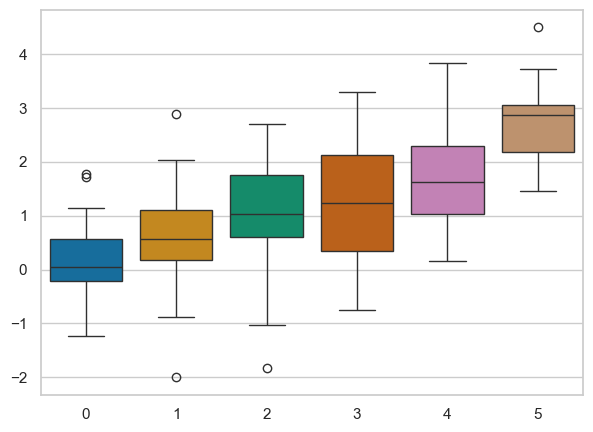

In [9]:
sns.set(style = "whitegrid",
        palette = "colorblind",
        rc = {'figure.figsize':(7,5)})
sns.boxplot(data=example_data);

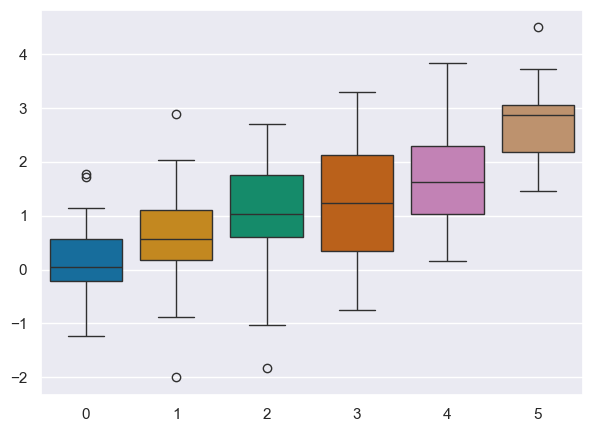

In [10]:
sns.set(style = "darkgrid",
        palette = "colorblind",
        rc = {'figure.figsize':(7,5)})
sns.boxplot(data=example_data);

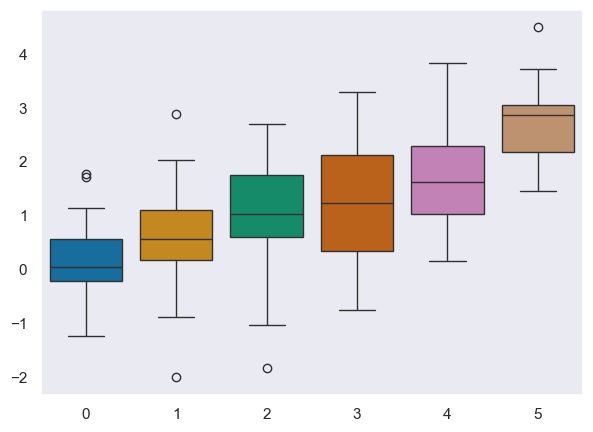

In [11]:
sns.set(style = "dark",
        palette = "colorblind",
        rc = {'figure.figsize':(7,5)})
sns.boxplot(data=example_data);

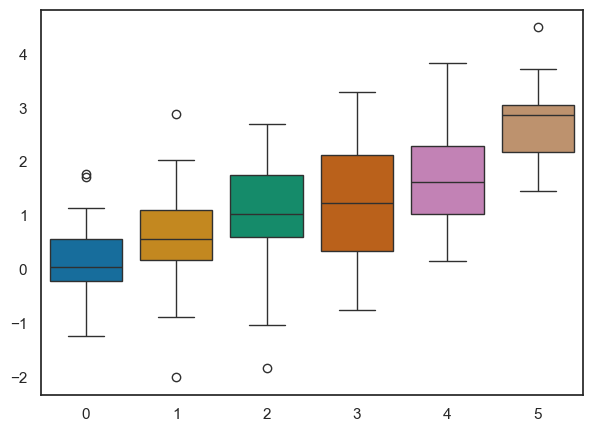

In [12]:
sns.set(style = "white",
        palette = "colorblind",
        rc = {'figure.figsize':(7,5)})
sns.boxplot(data=example_data);

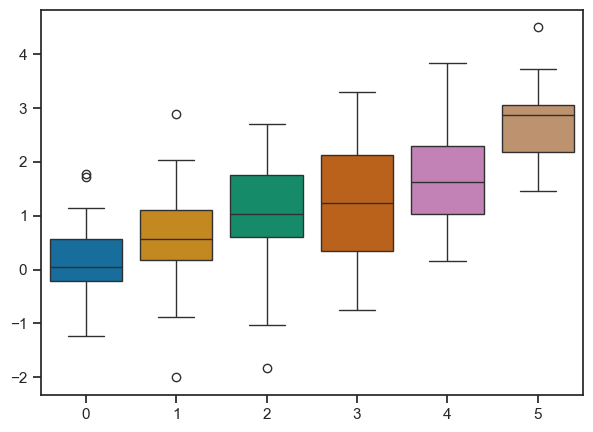

In [13]:
sns.set(style = "ticks",
        palette = "colorblind",
        rc = {'figure.figsize':(7,5)})
sns.boxplot(data=example_data);

In [14]:
sns.set(style = "whitegrid",
        palette = "colorblind",
        rc = 
        {'figure.figsize':(15,10), 
         'axes.titlesize': 14,
         'axes.labelsize': 12,
         'axes.grid':True,
         'grid.alpha':0.7,
         'grid.linestyle': ':',
         'xtick.labelsize':12,
         'ytick.labelsize':12}
) 

### 3. Create a joint plot that shows kernel density estimates of the distribution.

Use ‘hours-per-week’ on the x-axis and ‘Age’ on the y-axis.
Differentiate the distributions for two sexes using the jointplot() method’s hue argument.

In [15]:
sns.color_palette("colorblind")

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [16]:
print(sns.color_palette("colorblind").as_hex())

['#0173b2', '#de8f05', '#029e73', '#d55e00', '#cc78bc', '#ca9161', '#fbafe4', '#949494', '#ece133', '#56b4e9']


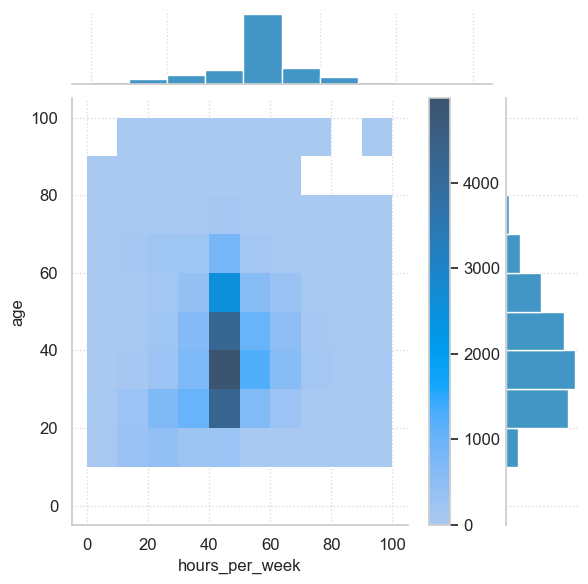

In [17]:
# In this example, both hours_per_week (x-axis) and age (y-axis) are divided into bins of width 10 (0–10, 10–20, …, 100–110). 
# The jointplot creates a 2D histogram where each square represents the number of rows that fall within the corresponding x–y bin.
bins = [i for i in range(0,110,10)]
g1 = sns.jointplot(data = df, x = "hours_per_week", y="age", kind = "hist",
                   joint_kws = {"bins": bins, "cbar":True},
                   marginal_kws = {"bins":bins}
                   )
plt.show()

#### Code Explanation
```python
bins = [i for i in range(0,110,10)]
```

* This creates the list `[0, 10, 20, ..., 100]`.
* These are the **bin edges**: 0–10, 10–20, … up to 100–110.
* So both `x` (`hours_per_week`) and `y` (`age`) will be divided into **intervals of width 10**.

---

```python
g1 = sns.jointplot(
    data=df,
    x="hours_per_week",
    y="age",
    kind="hist",
    joint_kws={"bins": bins, "cbar": True},
    marginal_kws={"bins": bins}
)
```

* `kind="hist"` means this is a **2D histogram** in the joint plot (the middle square grid).
* `joint_kws={"bins": bins}` passes the bin edges for both `x` and `y`.

  * That means the 2D plane is divided into **10×10 square bins** (hours bins × age bins).
* Each square represents the **count of observations** where:

  * `x` (hours) falls inside one bin, and
  * `y` (age) falls inside one bin.
* `cbar=True` adds a color bar, showing how the square color corresponds to counts.
* `marginal_kws={"bins": bins}` ensures the histograms along the top and side also use the same bins (so everything matches).

---

#### How a square bin is computed

Each bin is defined by:

$$
x_{\text{low}} \leq \text{hours\_per\_week} < x_{\text{high}}
$$

$$
y_{\text{low}} \leq \text{age} < y_{\text{high}}
$$

For example:

* Bin in the bottom-left: hours `[0,10)`, age `[0,10)`.
* Next bin right: hours `[10,20)`, age `[0,10)`.
* Next bin up: hours `[0,10)`, age `[10,20)`.

In [18]:
# Filtering the DataFrame for 40 ≤ hours_per_week < 50 and 10 ≤ age < 20 counts the number of observations in that specific square bin. 
df[ (df["hours_per_week"]>=40) &
    (df["hours_per_week"]<50) & 
    (df["age"]>=10) &
    (df["age"]<20)].age.count()

284

### Histograms vs. barplots
#### Histogram

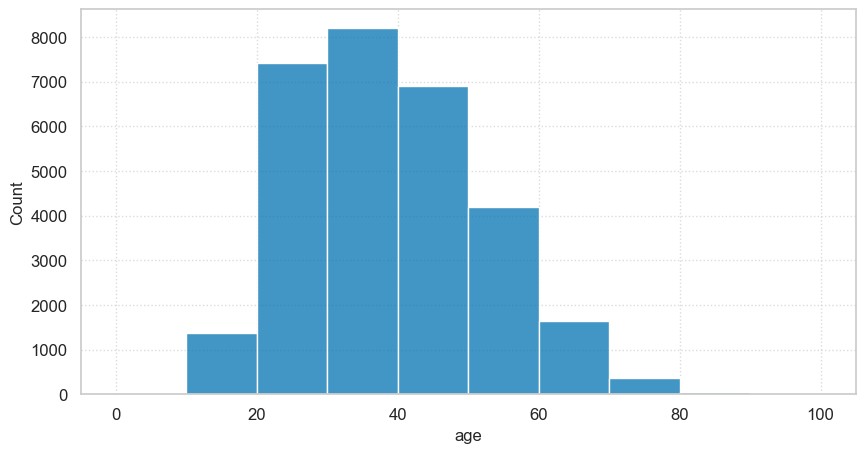

In [19]:
# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data = df, x = "age", bins = bins, ax = ax)
plt.show()

#### Code Explanation

#### **Histogram of Age**

##### What it is

* A **histogram** shows the **distribution of a single numeric variable** — in this case, `"age"`.
* The x-axis is divided into bins (intervals), and the height of each bar shows how many people fall into that age range.

##### Code details

```python
sns.histplot(
    data=df,
    x="age",
    bins=bins,
    ax=ax
)
```

* `x="age"` → plotting the `"age"` column.
* `bins=bins` → divides the ages into intervals like 0–10, 10–20, … 90–100 since the bin variable is the list `[0, 10, 20, ..., 100]`
* Each bar’s height = number of individuals in that age range.

##### How to read it

* The x-axis shows age ranges.
* The y-axis shows counts (how many people in each range).
* Taller bars = more people in that age range.

##### This plot helps answer:

* *What does the age distribution look like?*
* *Are there more younger or older individuals in the dataset?*
* *Which age ranges dominate?*


#### Barplot

Text(0, 0.5, 'Avg. Hours per Week')

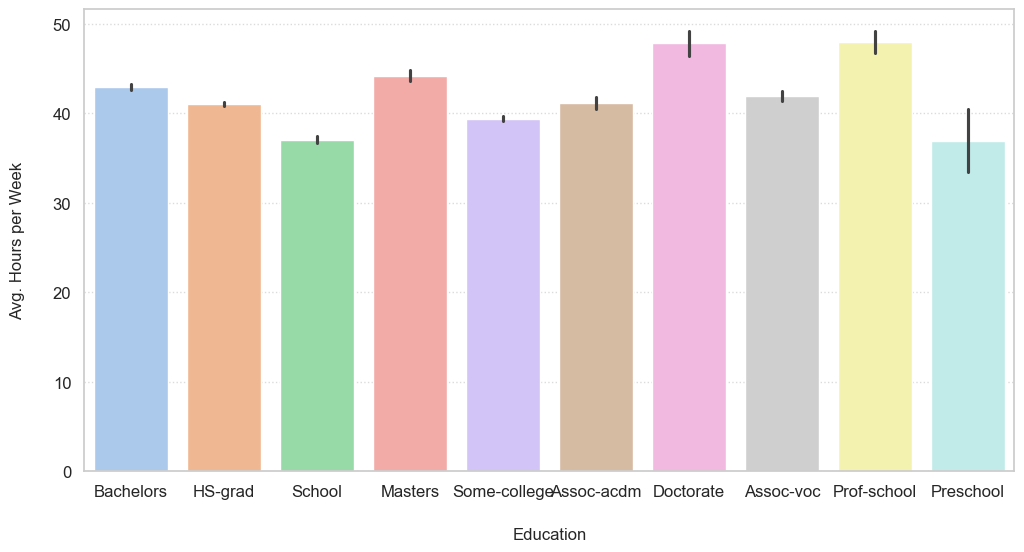

In [20]:
# Barplot
fig1, ax1 = plt.subplots(figsize = (12,6))
sns.barplot(
    data= df, 
    x = "education_sc",
    y = "hours_per_week",
    hue = "education_sc",
    estimator = "mean",
    palette = "pastel",
    ax = ax1
)
ax1.set_xlabel( 
    "Education",
    labelpad = 20.0)
ax1.set_ylabel(
    ylabel = "Avg. Hours per Week", 
    labelpad = 20.0)

#### Code Explanation

#### **Barplot of Education vs. Hours per Week**

##### What it is

* A **barplot** shows the relationship between a **categorical variable** (`education_sc`) and a **numeric variable** (`hours_per_week`).
* Here it shows the **average hours per week worked** for each education level.

##### Code details

```python
sns.barplot(
    data=df,
    x="education_sc",
    y="hours_per_week",
    hue="education_sc",
    estimator="mean",
    palette="pastel",
    ax=ax1
)
```

* `x="education_sc"` → categories on the x-axis.
* `y="hours_per_week"` → numeric values being computed.
* `hue="education_sc"` → colors bars differently for each category (here it duplicates x, so it’s more about style).
* `estimator="mean"` → each bar shows the **average hours per week** for that education group. The estimator parameter in Seaborn’s barplot is what decides how the numerical variable (y) is summarized for each category (x). By default, Seaborn computes the mean, but you can pass in any function that takes a vector of numbers and returns a single summary statistic (mean, median, len, sum, etc.)
* `palette="pastel"` → soft colors for clarity.
* Axis labels were customized with `set_xlabel` and `set_ylabel`.

##### How to read it

* Each bar corresponds to an education category.
* Bar height = mean hours worked per week for that group (because we used `estimator="mean"`).
* Differences in bar height tell you which groups work more or fewer hours on average.

##### This plot helps answer:

* *Do people with different education levels work different average hours per week?*
* *Which education group works the longest/shortest hours?*

---

#### Learning Points

* A **histogram** is great for looking at the **distribution** of a single numeric variable.
* A **barplot** is best for comparing **group averages** across categories.
* Both are easy to misinterpret if you forget what’s being summarized:

  * In a histogram, bar height = counts.
  * In a barplot, bar height = summary statistic (mean by default, but could be median or sum if changed).


#### Scatterplots

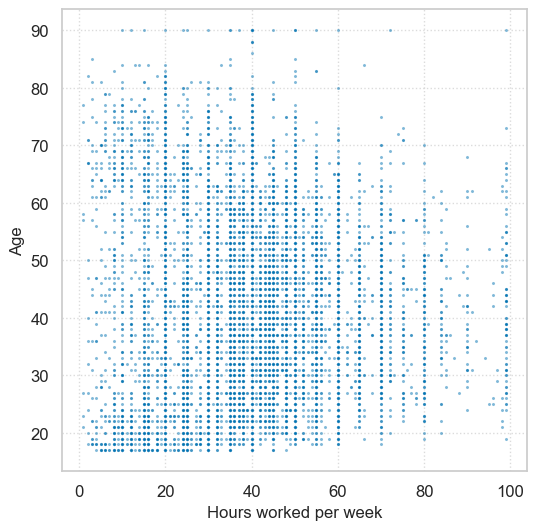

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(data = df, x = "hours_per_week", y="age", ax = ax, s =5, alpha = 0.5)
ax.set_xlabel( 
    "Hours worked per week")
ax.set_ylabel(
    ylabel = "Age")
fig.savefig(img_loc+'Scatterplot_hours_worked_vs_age.png', dpi = 300)
plt.show()

#### Code Explanation

#### **1. Plot Overview**

* A **scatterplot** shows the relationship between **two numeric variables**.
* Each dot represents **one individual/observation** in the dataset.
* Here:
  * The **x-axis** = `"hours_per_week"` (how many hours a person works).
  * The **y-axis** = `"age"` (the person’s age).
* By looking at where the dots cluster or spread, you can see whether there are patterns, trends, or unusual points.

This plot helps answer:

* *Do older and younger people work similar hours?*
* *Are there clusters of people around standard working hours (like 40 hours/week)?*
* *Are there outliers who work very high hours or are unusually young/old in the dataset?*

---

#### **2. Code Breakdown**

```python
fig, ax = plt.subplots(figsize=(6, 6))
```

* Creates a figure and axes (the plotting area), size 6×6 inches.

```python
sns.scatterplot(data=df, x="hours_per_week", y="age", ax=ax, s=5, alpha=0.5)
```

* `sns.scatterplot` → makes a scatterplot.
* `data=df` → takes the data from the DataFrame `df`.
* `x="hours_per_week"` → values along the x-axis.
* `y="age"` → values along the y-axis.
* `s=5` → makes the dots small (size = 5 points). Useful if there are many data points.
* `alpha=0.5` → makes the dots semi-transparent so overlapping points are easier to see.

```python
ax.set_xlabel("Hours worked per week")
ax.set_ylabel("Age")
```

* Sets custom axis labels for clarity.

```python
plt.show()
```

* Displays the finished plot.

---

#### **3. Questions for Reflecting on Visual Elements**

* Q1. What do you notice about the density of points — are there clusters around 40 hours per week?
* Q2. What do you notice about the transparency and size of the dots (`alpha=0.5`, `s=5`)?

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

* Q1. Do younger individuals (say under 20) show a different pattern of weekly hours compared to middle-aged groups?
* Q2. Is 40 hours/week a clear “spike” where many dots align vertically?
* Q3. Do older individuals (say over 65) tend to work fewer hours, or is there no clear pattern?
* Q4. Overall, does the scatterplot suggest a relationship between age and hours worked, or does it look mostly uncorrelated?

---

#### **5. Learning Points**

* **Key concepts shown:**

  * Scatterplots reveal relationships (or lack of them) between two numeric variables.
  * Transparency (`alpha`) helps when points overlap.
  * Adjusting dot size (`s`) makes large datasets easier to read.
* **When to use scatterplots:**

  * Best when you want to see relationships, clusters, or outliers in numeric data.
* **Common mistakes:**

  * Forgetting to adjust dot size/alpha → the plot looks like a solid blob if there are many points.
  * Misinterpreting clustering as a relationship when it might just reflect common values (like everyone working \~40 hours).
* **One improvement:**

  * Add a **trend line** (e.g., with `sns.regplot`) to see if there’s a weak upward or downward relationship between age and hours worked.

<details><summary style="font-size: 1.1em; font-weight: bold;">Click to show answers</summary>

#### Answers

#### **3. Questions for Reflecting on Visual Elements**

Q1. What do you notice about the density of points along the x-axis (hours worked per week)?

* The highest density is around **40 hours/week**, forming a strong vertical line.
* There are also smaller clusters near 20 and 60 hours, but 40 clearly dominates.

Q2. What do you notice about the transparency and size of the dots (`alpha=0.5`, `s=5`)?

* The small, semi-transparent points help reveal where there’s overlap.
* Darker regions indicate where many individuals share the same values (like at 40 hours).


#### **4. Data Interpretation: Explore these questions to deepen your understanding**

Q1. Do younger individuals (say under 20) show a different pattern of weekly hours compared to middle-aged groups?

* Yes. People under 20 are present in the dataset, but many of them are below the 40-hour mark, suggesting part-time or seasonal work. Compared to middle-aged groups (30–50), their hours are more scattered and often lower.

Q2. Is 40 hours/week a clear “spike” where many dots align vertically?

* Absolutely. There’s a dense vertical line at 40 hours/week that cuts across nearly all age groups. This reflects the standard full-time work week, and it’s the single most prominent feature of the scatterplot.

Q3. Do older individuals (say over 65) tend to work fewer hours, or is there no clear pattern?

* Many over 65 appear in the dataset, but most of them fall below 40 hours/week. While some still work 40 hours, the overall density is lower, consistent with partial retirement or reduced work schedules.

Q4. Overall, does the scatterplot suggest a relationship between age and hours worked, or does it look mostly uncorrelated?

* Overall, there’s no strong linear relationship: people of all ages can work 40 hours.
* However, there are **age-related nuances**:

  * Younger (<20) → fewer hours on average.
  * Middle-aged (30–50) → cluster strongly at 40 hours.
  * Older (>65) → more likely to drop below 40.
* So, the pattern is not a correlation in the statistical sense, but rather **clusters shaped by social norms** (full-time work at 40 hours, with deviations for very young and very old groups).

---

**Key takeaway:**
The scatterplot shows that “hours worked per week” is more influenced by labor conventions (40 hours = full-time) than by age itself, though the youngest and oldest groups deviate from that norm.

</summary>

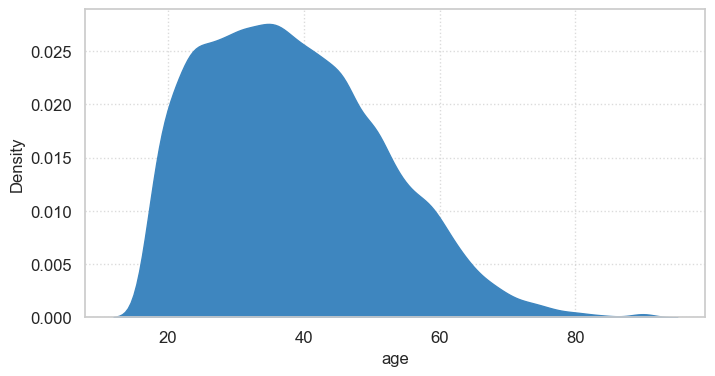

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data = df,  x="age", color = "#3E86BF", fill=True, alpha = 1, ax=ax)
fig.savefig(img_loc+'KDE_age.png', dpi = 300)
plt.show()

#### Code Explanation

#### **1. Plot Overview**

* This is a **KDE plot** of the variable `age`.
* A KDE is essentially a smoothed histogram: instead of discrete bars, you see a continuous curve that estimates the probability density of ages in the dataset.
* The x-axis represents age, while the y-axis (Density) indicates how common different ages are, scaled so the total area under the curve is 1.

This plot helps answer:

* *What is the age distribution of individuals in the dataset?*
* *Where are the peaks (most common ages), and how does the distribution thin out at the extremes?*

---

#### **2. Code Breakdown**

```python
fig, ax = plt.subplots(figsize=(8, 4))
```

* Creates a figure (8 inches wide, 4 inches tall) with one set of axes.

```python
sns.kdeplot(data=df, x="age", color="#3E86BF", fill=True, alpha=1, ax=ax)
```

* `sns.kdeplot` → makes the kernel density estimate plot.
* `data=df, x="age"` → plots the distribution of the `age` column.
* `color="#3E86BF"` → sets the curve/fill to a blue shade.
* `fill=True` → fills the area under the KDE curve.
* `alpha=1` → fully opaque fill.
* `ax=ax` → draws the KDE on the previously created axes.

```python
fig.savefig(img_loc+'KDE_age.png', dpi=300)
```

* Saves the figure as a high-resolution PNG file.

```python
plt.show()
```

* Displays the plot.

---

#### **3. Questions for Reflecting on Visual Elements**

* Q1. How would you describe the effect of filling the area under the curve compared to just drawing the line?

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

* Q1. Where is the peak of the distribution, and what does that suggest about the most common ages in the dataset?
* Q2. Does the distribution look symmetric, skewed left, or skewed right?
* Q3. How does the density of younger individuals compare to older individuals?
* Q4. What does the long tail to the right (into older ages) suggest about the population?

**Answering based on the plot:**

* The peak occurs around ages 30–40, meaning most individuals are in this range.
* The distribution is right-skewed: many people are younger or middle-aged, while fewer are older.
* Density declines gradually after 40, and especially after 60, showing fewer individuals in those age brackets.
* The small tail beyond 80–90 suggests there are only a handful of very elderly individuals in the dataset.

---

#### **5. Learning Points**

* **Key Matplotlib/Seaborn concept:** KDE plots smooth out histograms and highlight the shape of a distribution.
* **When to use:** Ideal when you want to see the *overall distribution* of a numeric variable, especially when it’s continuous like age, income, or temperature.
* **Common mistakes:**

  * Using KDE for discrete variables (e.g., counts or categorical codes).
  * Forgetting that the y-axis is *density*, not raw counts.

---

*Key takeaway:** The KDE plot shows that the dataset’s population is concentrated between 20–50 years old, with far fewer people at older ages, producing a right-skewed distribution.

<details><summary style="font-size: 1.1em; font-weight: bold;">Click to show answers</summary>

#### Answers

#### **3. Questions for Reflecting on Visual Elements**

**Q1. How would you describe the effect of filling the area under the curve compared to just drawing the line?**

* The filled area makes the distribution easier to read because the density "volume" is more visible.
* Without the fill, the plot would just look like a line; with the fill, it feels more like a "mountain" showing where the bulk of the data lies.

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

**Q1. Where is the peak of the distribution, and what does that suggest about the most common ages in the dataset?**

* The peak is around **30–40 years**, suggesting that most respondents fall into this working-age group.

**Q2. Does the distribution look symmetric, skewed left, or skewed right?**

* It looks right-skewed: there’s a long tail extending toward older ages.

**Q3. How does the density of younger individuals compare to older individuals?**

* Younger individuals (<20) appear less frequently than middle-aged adults, and older individuals (>60) are even less common, which explains the tapering tails on both sides.

**Q4. What does the long tail to the right (into older ages) suggest about the population?**

* It suggests that while most people are younger to middle-aged, there are still some older individuals present, though they are relatively few compared to the peak group.

---

**Key takeaway:** The KDE plot highlights that the dataset is dominated by adults in their 30s and 40s, with fewer very young and very old participants, and an overall right-skewed distribution.
    
</summary>

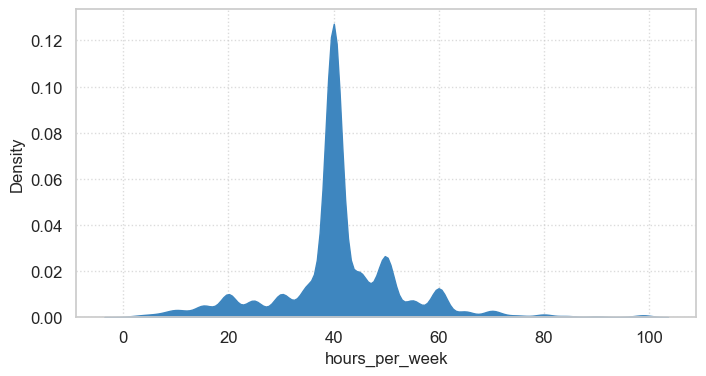

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(data = df,  x="hours_per_week", color = "#3E86BF", fill=True, alpha = 1, ax=ax)
plt.show()

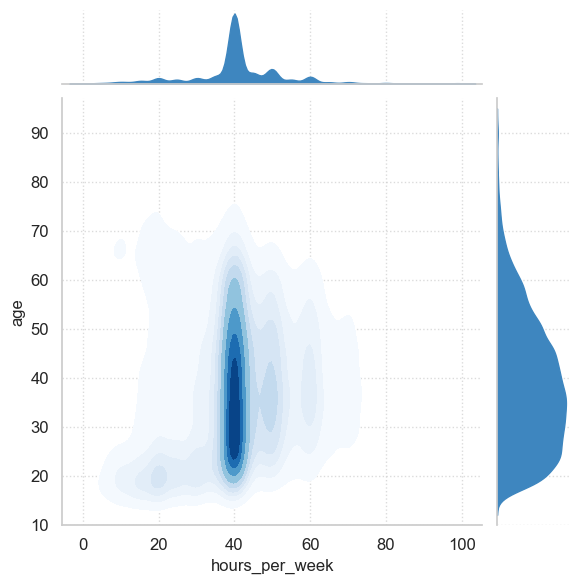

In [24]:
sns.jointplot(data = df, x = "hours_per_week", y="age", kind = "kde", 
              joint_kws = dict(cmap="Blues", fill=True, ),
              marginal_kws = dict(color = "#3E86BF", fill=True, alpha = 1)
             )
plt.show()

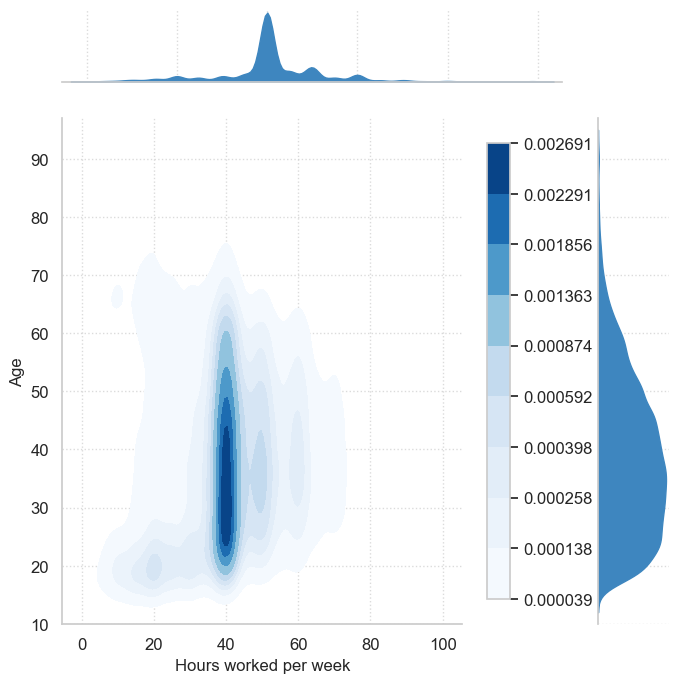

In [25]:
g = sns.jointplot(data = df, x = "hours_per_week", y="age", kind = "kde", space = 0.5, height = 7,
              joint_kws = dict(cmap="Blues", fill=True, cbar=True, cbar_kws = {"shrink":0.9}),
              marginal_kws = dict(color = "#3E86BF", fill=True, alpha = 1)
             )
# Add axis labels
g.set_axis_labels("Hours worked per week", "Age", fontsize=12)
g.figure.savefig(img_loc+'joint_age_hours.png', dpi = 300)
plt.show()

#### Code Explanation

#### **1. Plot Overview**

* This is a **bivariate KDE joint plot**.
* The central panel shows the **joint distribution** of two variables:

  * **x-axis**: *Hours worked per week*
  * **y-axis**: *Age*
* The color contours represent areas of higher or lower probability density.
* The side plots (top and right) show the **marginal KDEs** — the distributions of *hours worked per week* and *age* individually.
* The colorbar on the right maps the KDE density values to colors.

This visualization helps answer:

* *How are age and hours worked related?*
* *Where do the data points cluster most strongly?*
* *What are the typical ranges for age and weekly hours?*

---

#### **2. Code Breakdown**

```python
sns.jointplot(
    data=df, 
    x="hours_per_week", 
    y="age", 
    kind="kde", 
    space=0.5, 
    height=7,
    joint_kws=dict(cmap="Blues", fill=True, cbar=True, cbar_kws={"shrink":0.9}),
    marginal_kws=dict(color="#3E86BF", fill=True, alpha=1)
)
```

* `kind="kde"` → uses kernel density estimation instead of scatter/hist.
* `joint_kws` → passes options to the central KDE plot:

  * `cmap="Blues"` → blue colormap.
  * `fill=True` → filled contours.
  * `cbar=True` → adds a colorbar.
* `marginal_kws` → styles the marginal distributions (color, fill, alpha).
* `space=0.5` → spacing between joint and marginal axes.
* `height=7` → figure size in inches.

---

#### **3. Questions for Reflecting on Visual Elements**

* Q1. What role does the colorbar play in helping you interpret density levels?
* Q2. If you imagine the joint KDE plot as a landscape, what does it resemble, and how does that help you interpret it?

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

* Q1. Where is the highest density of individuals located in the joint plot?
* Q2. What does the marginal KDE of hours worked suggest?
* Q3. How does age distribution appear in the marginal KDE?
* Q4. Is there a strong correlation between age and hours worked?

---

#### **5. Learning Points**

* **KDE joint plots** allow you to see both *joint* and *marginal* distributions in one figure.
* They are particularly useful for detecting clusters and typical ranges.
* **Common mistake**: forgetting that KDE smooths data — the contours don’t show raw counts but a smoothed estimate of density.
* **Improvement idea**: overlay actual scatter points (with `kind="kde"` + `sns.scatterplot`) to connect density estimates back to raw data.

---

**Key takeaway:**
The joint plot shows that most people in the dataset are between 20–50 years old and typically work \~40 hours per week. Hours worked is strongly centered at 40 regardless of age, indicating that cultural/workplace norms, rather than age, drive this pattern.


<details><summary style="font-size: 1.1em; font-weight: bold;">Click to show answers</summary>

#### Answers


#### **3. Questions for Reflecting on Visual Elements**


**Q1. What role does the colorbar play in helping you interpret density levels?**

* The colorbar links shades of blue to density values, so darker shades mean more people. It helps you quantify how strong a cluster is, not just see it qualitatively.

**Q2. If you imagine the joint KDE plot as a landscape, what does it resemble, and how does that help you interpret it?**

* The KDE looks like the **picture of a mountain**: the tallest, darkest “peak” is at 40 hours/week and ages 30–50, where most people are concentrated. The lighter contour bands spread outward like slopes, showing areas with fewer individuals. Thinking of it as a mountain makes it clear that the dataset has a single dominant peak (the “summit” at 40 hours), while the density falls off gradually in all directions.

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

**Q1. Where is the highest density of individuals located in the joint plot?**

* Around 40 hours/week and ages 30–50.

**Q2. What does the marginal KDE of hours worked suggest?**

* The vast majority of people work exactly around 40 hours, with very few working much less or much more.

**Q3. How does age distribution appear in the marginal KDE?**

* It’s skewed: the bulk of individuals are younger to middle-aged adults (20–50), with steadily fewer older individuals.

**Q4. Is there a strong correlation between age and hours worked?**

* No — the hours worked are centered at 40 across all ages. Instead of correlation, the pattern shows that social/work norms (40 hours/week) dominate across age groups.


</summary>

In [26]:
from matplotlib.colors import LinearSegmentedColormap

In [27]:
# Define the original colormap
blues_cmap = sns.color_palette("Blues", as_cmap=True)

In [28]:
# Extract a subset of the colormap (e.g., 30% to 100% range)
blues_range = blues_cmap(np.linspace(0.1, 1, 256))
subset_cmap = LinearSegmentedColormap.from_list("Blues_subset", blues_range)

<Axes: >

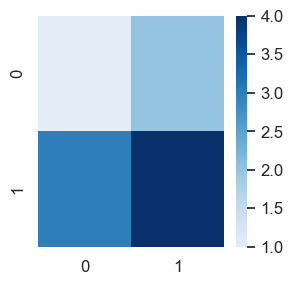

In [29]:
fig, ax = plt.subplots(figsize=(3, 3))
sns.heatmap([[1, 2], [3, 4]], cmap=subset_cmap)

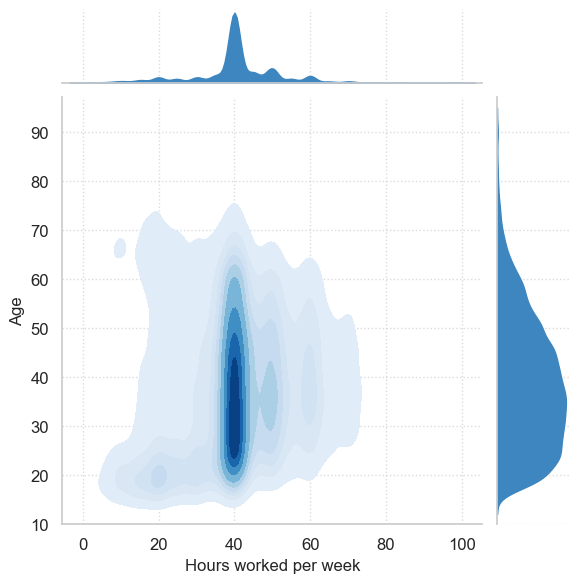

In [30]:
# jointplot with a substet of the color palette
g = sns.jointplot(data = df, x = "hours_per_week", y="age", kind = "kde", 
              joint_kws = dict(cmap=subset_cmap, fill=True),
              marginal_kws = dict(color = "#3E86BF", fill=True, alpha = 1)
             )
g.set_axis_labels("Hours worked per week", "Age", fontsize=12)
plt.show()

In [31]:
# Extract another subset of the colormap (e.g., 30% to 100% range)
blues_range2 = blues_cmap(np.linspace(0.3, 1, 256))
subset_cmap2 = LinearSegmentedColormap.from_list("Blues_subset2", blues_range2)

<Axes: >

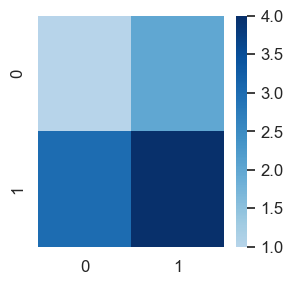

In [32]:
fig, ax = plt.subplots(figsize=(3, 3))
sns.heatmap([[1, 2], [3, 4]], cmap=subset_cmap2)

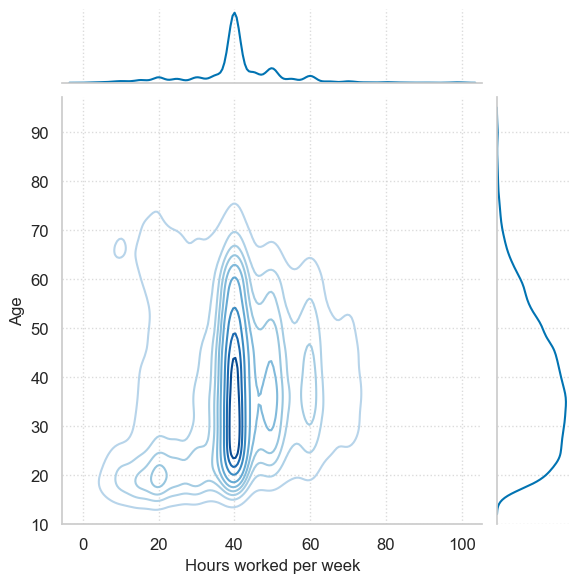

In [33]:
g = sns.jointplot(data = df, x = "hours_per_week", y="age", kind = "kde", 
              joint_kws = dict(cmap=subset_cmap2, fill=False),
              marginal_kws = dict(fill=False)
             )
g.set_axis_labels("Hours worked per week", "Age", fontsize=12)
g.figure.savefig(img_loc+'joint_age_hours_2.png', dpi = 300)
plt.show()

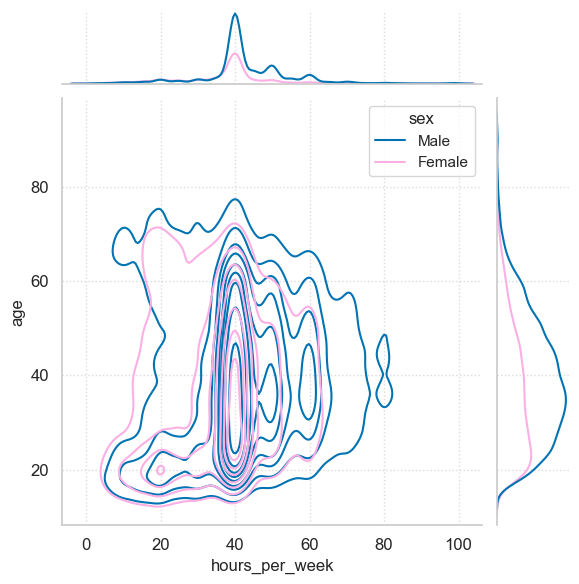

In [34]:
g1 = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   hue="sex", hue_order = ["Male","Female"],
                   kind = "kde",
                   palette = ['#0173b2','#fbafe4'])
g.set_axis_labels("Hours worked per week", "Age", fontsize=12)
g.figure.savefig(img_loc+'joint_age_hours_M_F.png', dpi = 300)
plt.show()

#### Code Explanation

#### **1. Plot Overview**

* This is a **bivariate KDE joint plot** of:

  * **x-axis**: *Hours worked per week*
  * **y-axis**: *Age*
* The data are split by the categorical variable **sex** using the `hue` parameter.
* Two KDE contour maps are drawn on the same axes:

  * **Blue (`#0173b2`)** = Male
  * **Pink (`#fbafe4`)** = Female
* The top and right marginal plots show the distribution of each variable separately, also separated by sex.

This plot helps answer:

* *Do men and women have different age–hours worked distributions?*
* *Where do the two groups overlap, and where do they differ?*

---

#### **2. Code Breakdown**

```python
g1 = sns.jointplot(
    data=df, 
    x="hours_per_week", 
    y="age", 
    hue="sex", 
    hue_order=["Male","Female"],
    kind="kde",
    palette=['#0173b2','#fbafe4']
)
```

* `hue="sex"` → KDE contours are split by male and female.
* `hue_order` → ensures that the legend lists *Male* first, then *Female*.
* `kind="kde"` → plots kernel density contours instead of scatter/hist.
* `palette` → sets custom colors for each group.

```python
g.set_axis_labels("Hours worked per week", "Age", fontsize=12)
```

* Adds descriptive axis labels.

```python
g.figure.savefig(img_loc+'joint_age_hours_M_F.png', dpi=300)
```

* Saves the figure as a high-resolution PNG.

---

#### **3. Questions for Reflecting on Visual Elements**


* Q1. How does the color-coding (blue vs pink) help distinguish patterns that would be hidden in a single KDE?

* Q2. If you view the joint KDE as a landscape, can you identify the “highest peak” from this plot?

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

* Q1. Where do men and women show the strongest similarity?

* Q2. Where might there be differences between men and women?

* Q3. Does the plot suggest a strong gender difference in working hours by age?

* Q4. What does the strong overlap of contours imply about the dataset?

---

#### **5. Learning Points**

* Adding `hue` in joint plots lets you compare two subpopulations directly in both joint and marginal distributions.
* Overlap vs. separation in contours is a quick way to spot differences or similarities between groups.
* **Common mistake:** interpreting small differences as significant — KDEs are smooth estimates and may exaggerate or hide details at the extremes.
* **Improvement idea:** Overlay raw scatter points for both sexes with transparency to see the underlying data behind the KDE.

---

**Key takeaway:**
The joint KDE plot shows that both men and women are overwhelmingly concentrated around 40 working hours per week in adulthood, with only subtle differences in spread — suggesting that full-time work norms dominate across sex.


<details><summary style="font-size: 1.1em; font-weight: bold;">Click to show answers</summary>

#### Answers
#### **3. Questions for Reflecting on Visual Elements**

**Q1. How does the color-coding (blue vs pink) help distinguish patterns that would be hidden in a single KDE?**

* The separate contours reveal subtle differences: men and women are similar at 40 hours, but may differ in spread at very high or very low hours.

**Q2. If you view the joint KDE as a landscape, can you identify the “highest peak” from this plot?**

* Not unambiguously. Because the contours are drawn with similar styling and there’s no filled color scale or numeric labels on the levels, the plot only shows shape (where density changes) but not the height (which level is greater). You can see where the rings cluster (suggesting a dense region), but you can’t assert which area is the absolute maximum or whether one group peaks higher than the other.

---

#### **4. Data Interpretation: Explore these questions to deepen your understanding**

**Q1. Where do men and women show the strongest similarity?**

* Both groups cluster tightly around 40 hours/week for working adults between 30 and 50 years old.

**Q2. Where might there be differences between men and women?**

* Men may show a broader spread in hours (some working higher weekly hours), while women may be more concentrated in a narrower band around 40.
* In age distribution, men may have more representation in older age brackets.

**Q3. Does the plot suggest a strong gender difference in working hours by age?**

* No — the biggest takeaway is similarity: both groups follow the same dominant pattern, centered on 40 hours across many ages.

**Q4. What does the strong overlap of contours imply about the dataset?**

* That sex is not a strong differentiator for weekly hours worked when age is also considered; workplace norms (40-hour weeks) dominate across both groups.
    
</summary>

### Jointplot using `jointplot`

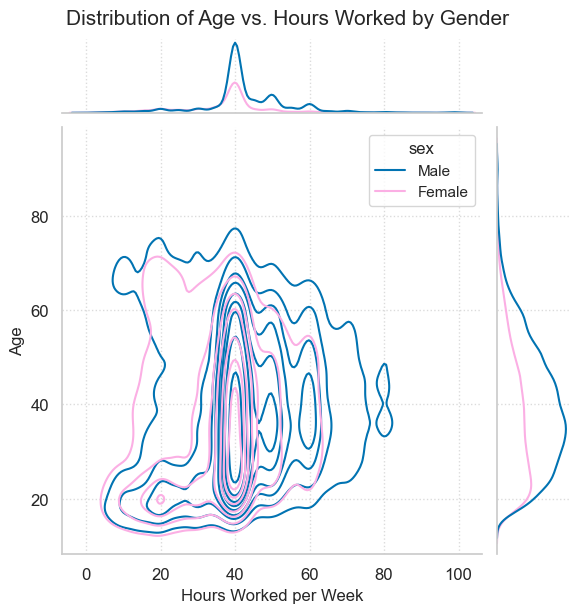

In [35]:
g1 = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   hue="sex", hue_order = ["Male","Female"],
                   kind = "kde",
                   palette = ['#0173b2','#fbafe4'])
g1.set_axis_labels(xlabel = "Hours Worked per Week", 
                   ylabel = "Age")
grid_title = "Distribution of Age vs. Hours Worked by Gender"
g1.figure.suptitle(grid_title, 
                   size = 15, y = 1.02)
plt.show()

### Jointplot using `JointGrid`, `plot_joint`, and `plot_marginals`

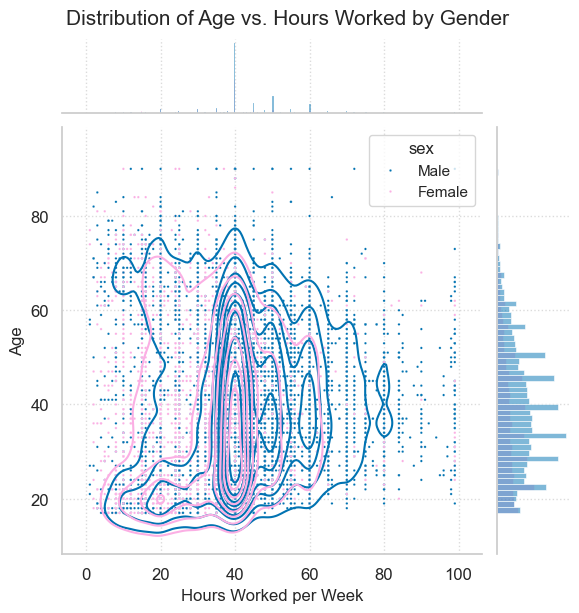

In [36]:
g1 = sns.JointGrid(data = df, x = "hours_per_week", y="age", 
                   hue="sex", hue_order = ["Male","Female"],
                   palette = ['#0173b2','#fbafe4'])
g1.plot_joint(sns.kdeplot)
g1.plot_joint(sns.scatterplot, s=3)
g1.plot_marginals(sns.histplot)
g1.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
g1.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 15, y = 1.02)
plt.show()

### Jointplot with `JointGrid` and `plot`

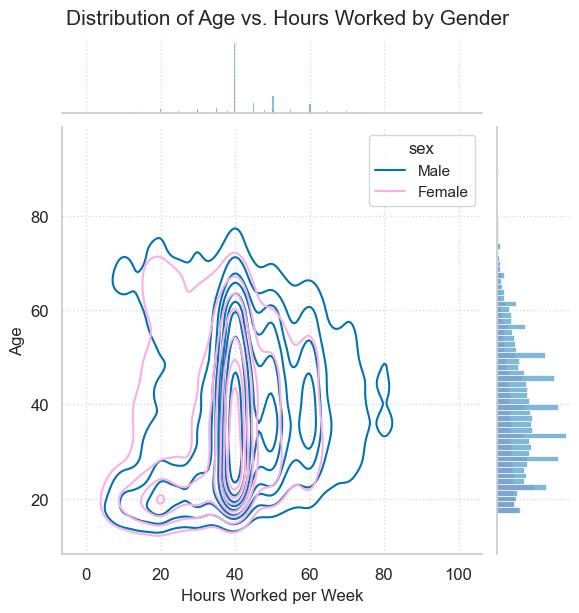

In [37]:
g1 = sns.JointGrid(data = df, x = "hours_per_week", y="age", 
                   hue="sex", hue_order = ["Male","Female"],
                   palette = ['#0173b2','#fbafe4'])
g1.plot(sns.kdeplot, sns.histplot)
g1.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
g1.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 15, y = 1.02)
plt.show()

### Jointplot with `JointGrid` accessing the different axes

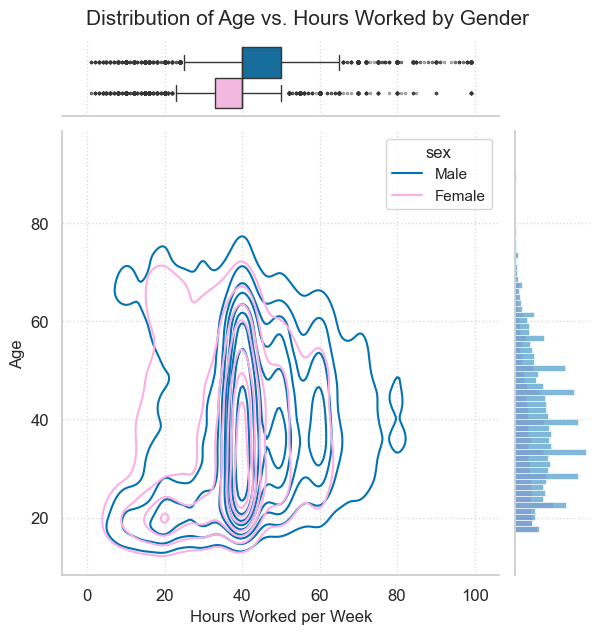

In [38]:
g1 = sns.JointGrid()
sns.kdeplot(data = df, x = "hours_per_week", y="age", hue="sex", hue_order = ["Male","Female"],
                   palette = ['#0173b2','#fbafe4'], ax = g1.ax_joint,) 
sns.boxplot(data = df, x = "hours_per_week", hue="sex", hue_order = ["Male","Female"],
                   flierprops=dict(marker='o', markersize=1.5, alpha = 0.5),
                   palette = ['#0173b2','#fbafe4'], legend = False,  ax = g1.ax_marg_x)
sns.histplot(data = df, y="age", hue="sex", hue_order = ["Male","Female"],
                   palette = ['#0173b2','#fbafe4'], legend = False, ax = g1.ax_marg_y)
g1.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
g1.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 15, y = 1.02)
plt.show()

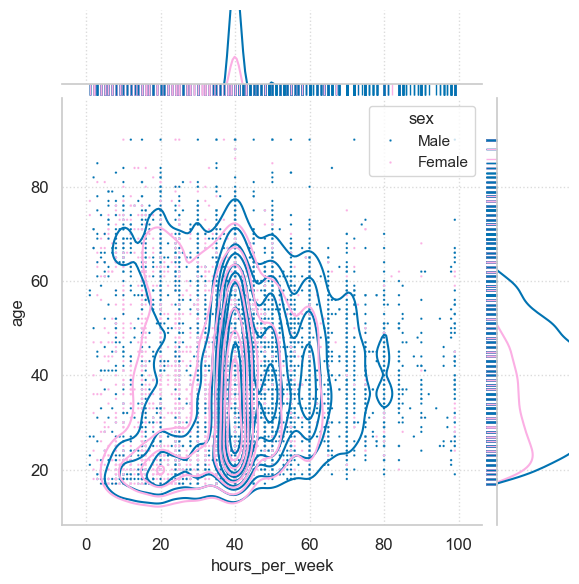

In [39]:
g1 = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   hue="sex", 
                   hue_order = ["Male","Female"],
                   kind = "kde",
                   palette = ['#0173b2','#fbafe4'])

g1.plot_joint(sns.scatterplot, s=3)

g1.plot_marginals(sns.rugplot, height=-.15, clip_on=False)

plt.show()

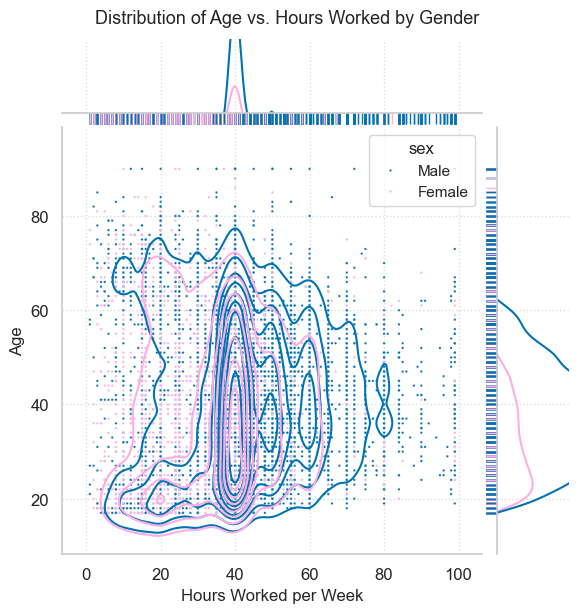

In [40]:
g1 = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   hue="sex", 
                   hue_order = ["Male","Female"],
                   kind = "kde",
                   palette = ['#0173b2','#fbafe4'])
g1.plot_joint(sns.scatterplot, s=3)
g1.plot_marginals(sns.rugplot, height=-.15, clip_on=False)

g1.set_axis_labels(xlabel = "Hours Worked per Week", 
                   ylabel = "Age")
grid_title = "Distribution of Age vs. Hours Worked by Gender"
g1.figure.suptitle(grid_title, size = 13, y = 1.02)

g1.savefig(img_loc+"P3_M3_jointplot.png", dpi = 400)

plt.show()

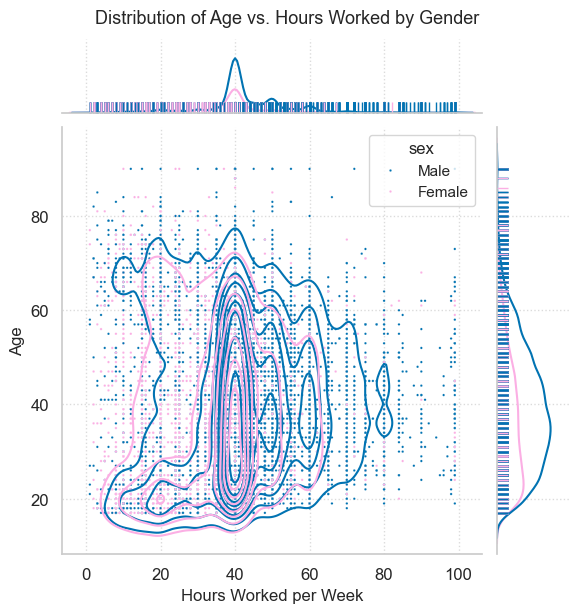

In [41]:
g1 = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   hue="sex", 
                   hue_order = ["Male","Female"],
                   kind = "kde",
                   palette = ['#0173b2','#fbafe4'])
g1.plot_joint(sns.scatterplot, s=3)
g1.plot_marginals(sns.rugplot, height=.15, clip_on=False)

g1.set_axis_labels(xlabel = "Hours Worked per Week", 
                   ylabel = "Age")
grid_title = "Distribution of Age vs. Hours Worked by Gender"
g1.figure.suptitle(grid_title, size = 13, y = 1.02)

g1.savefig(img_loc+"P3_M3_jointplot.png", dpi = 400)

plt.show()

In [42]:
type(g1)

seaborn.axisgrid.JointGrid

### Jointplot with `jointplot`

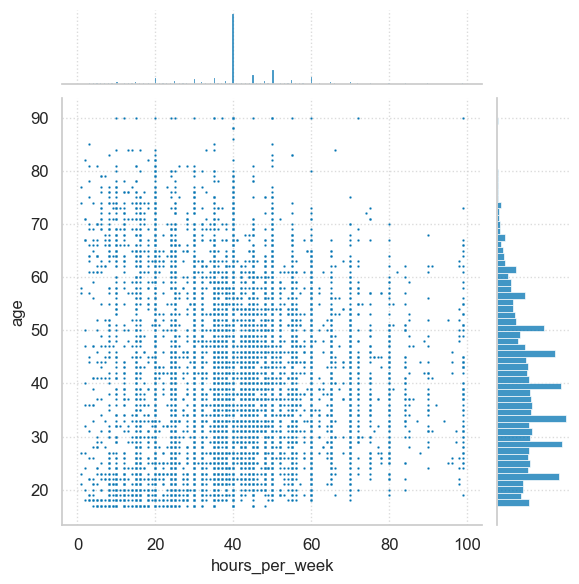

In [43]:
g1 = sns.jointplot(data = df, x = "hours_per_week", y="age", kind = "scatter",
                   joint_kws = {"s":3}
                   )
plt.show()

### Jointplot with `JointGrid`

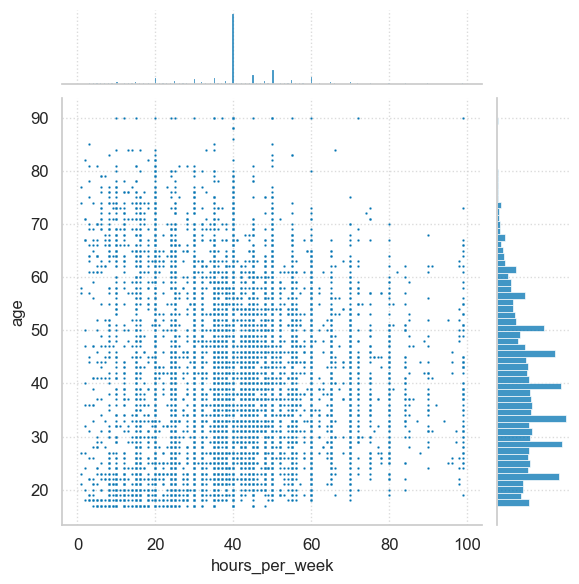

In [44]:
g1 = sns.JointGrid(data = df, x = "hours_per_week", y="age")
g1.plot_joint(sns.scatterplot, s=3)
g1.plot_marginals(sns.histplot)
plt.show()

### Extra Examples

#### KDE and Contour plots

In [45]:
# Example data
data = sns.load_dataset("iris")

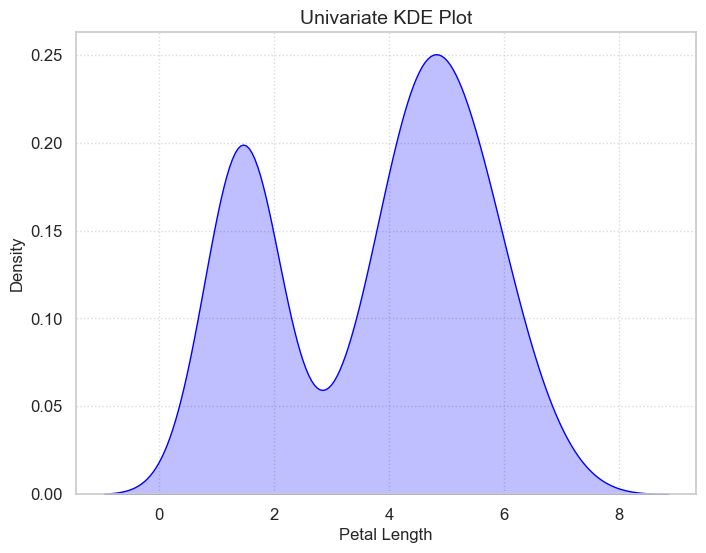

In [46]:
# Univariate contour plot
# Univariate KDE plot for petal_length
fig, ax = plt.subplots(figsize=(8, 6))
sns.kdeplot(data['petal_length'], fill=True, color="blue", ax = ax)
plt.title("Univariate KDE Plot")
plt.xlabel("Petal Length")
plt.ylabel("Density")
plt.show()


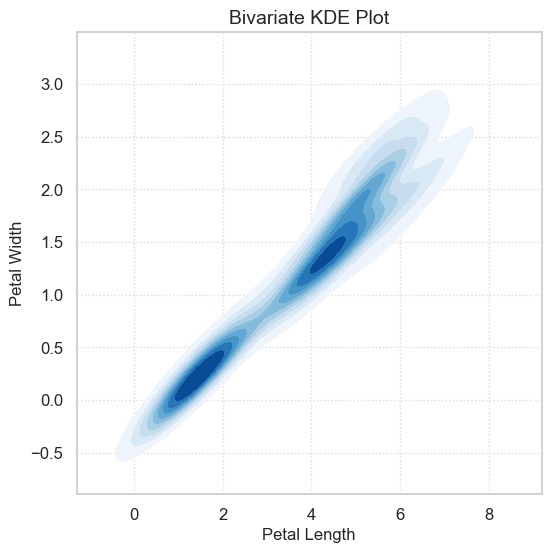

In [47]:
# Bivariate KDE plot for petal_length and petal_width
fig, ax = plt.subplots(figsize=(6, 6))
sns.kdeplot(x=data['petal_length'], y=data['petal_width'], cmap="Blues", fill=True, ax=ax)
plt.title("Bivariate KDE Plot")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

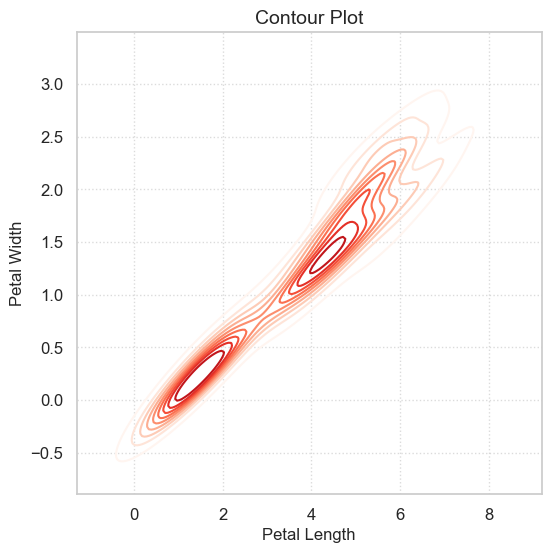

In [48]:
# Contour plot for petal_length and petal_width
fig, ax = plt.subplots(figsize=(6, 6))
sns.kdeplot(x=data['petal_length'], y=data['petal_width'], cmap="Reds", fill=False, ax=ax)
plt.title("Contour Plot")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

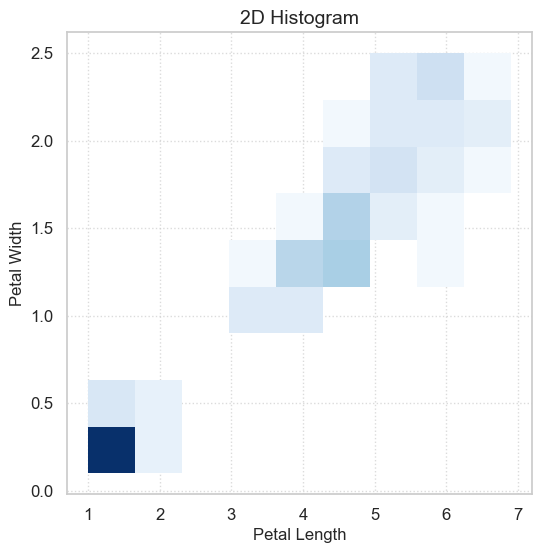

In [49]:
# Bivariate KDE plot for petal_length and petal_width
fig, ax = plt.subplots(figsize=(6, 6))
sns.histplot(x=data['petal_length'], y=data['petal_width'], cmap="Blues", fill=True, ax=ax)
plt.title("2D Histogram")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

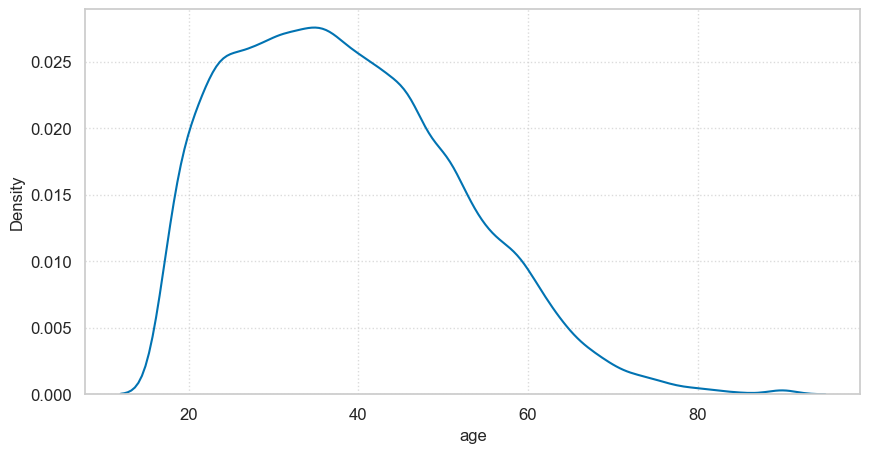

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data = df, x = "age", ax = ax)
plt.show()

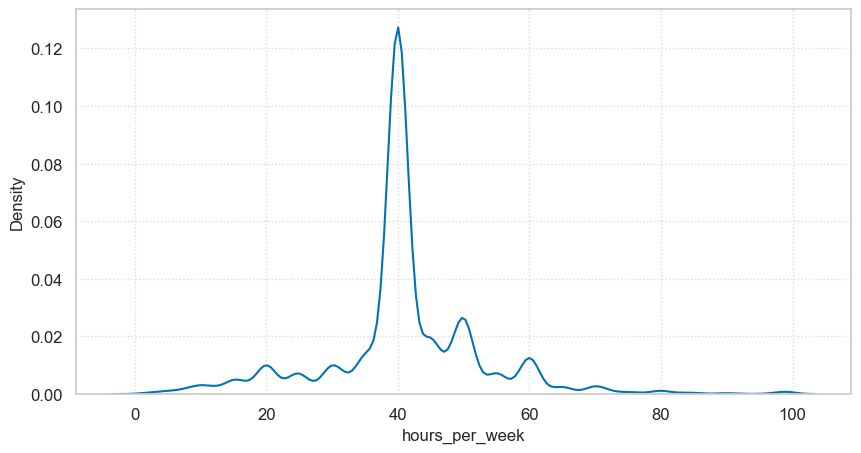

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data = df, x = "hours_per_week", ax = ax)
plt.show()

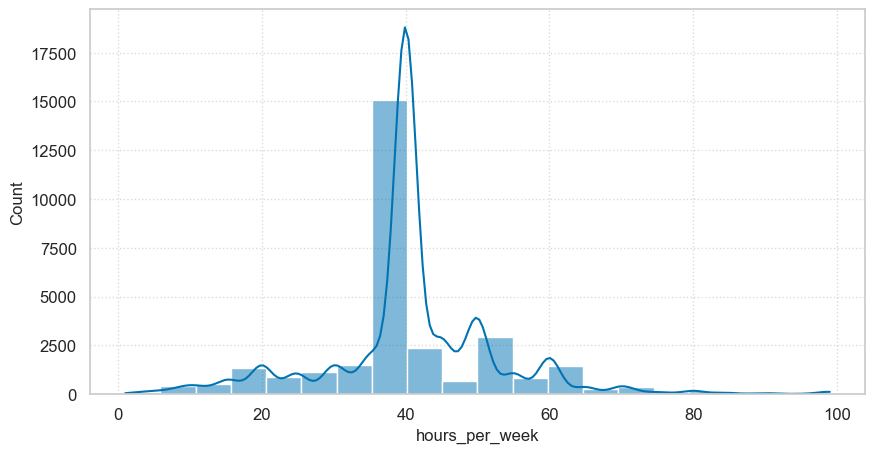

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data = df, x = "hours_per_week", bins = 20, kde = True, ax = ax)
plt.show()

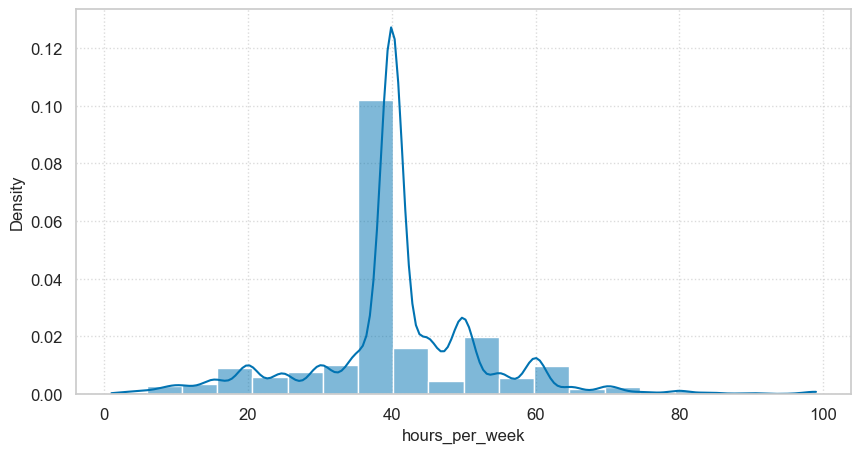

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data = df, x = "hours_per_week", bins = 20, kde = True, stat = "density", ax = ax)
plt.show()

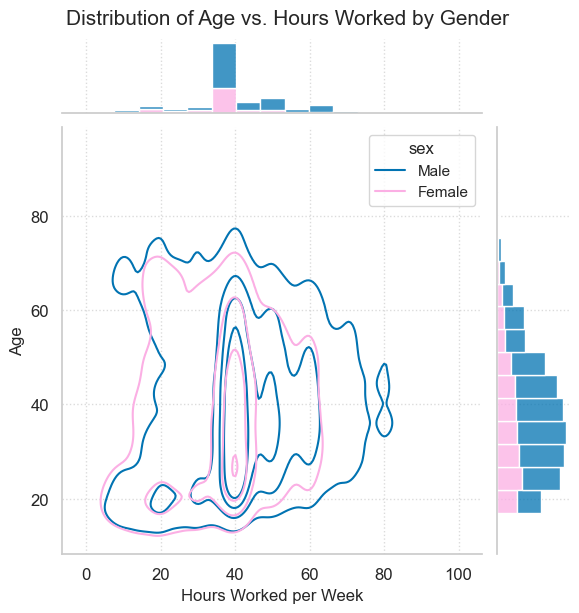

In [54]:
g1 = sns.JointGrid(data = df, x = "hours_per_week", y="age", 
                   hue="sex", hue_order = ["Male","Female"],
                   palette = ['#0173b2','#fbafe4'])
g1.plot_joint(sns.kdeplot, levels = 5)
g1.plot_marginals(sns.histplot, bins = 15, multiple = "stack")
g1.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
g1.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 15, y = 1.02)
plt.show()

In [55]:
g1.figure.axes

[<Axes: xlabel='Hours Worked per Week', ylabel='Age'>,
 <Axes: xlabel='hours_per_week', ylabel='Count'>,
 <Axes: xlabel='Count', ylabel='age'>]

### 4. Set axis labels and plot title and save your plot as a png file with the desired resolution.

### 5. Create a jointplot with kernel density estimates and marginals.
You can use the plot_joint() function to add multiple plots to the jointgrid instance returned by the Seaborn jointplot() method.   
In this step, create a jointgrid instance by calling sns.jointplot().    
Add kdeplot and rugplot to the jointgrid.

#### Using jointplot

### 6. Set axis labels and plot title and save your plot as a png file with the desired resolution.

### Variations

#### Using JointGrid and its methods

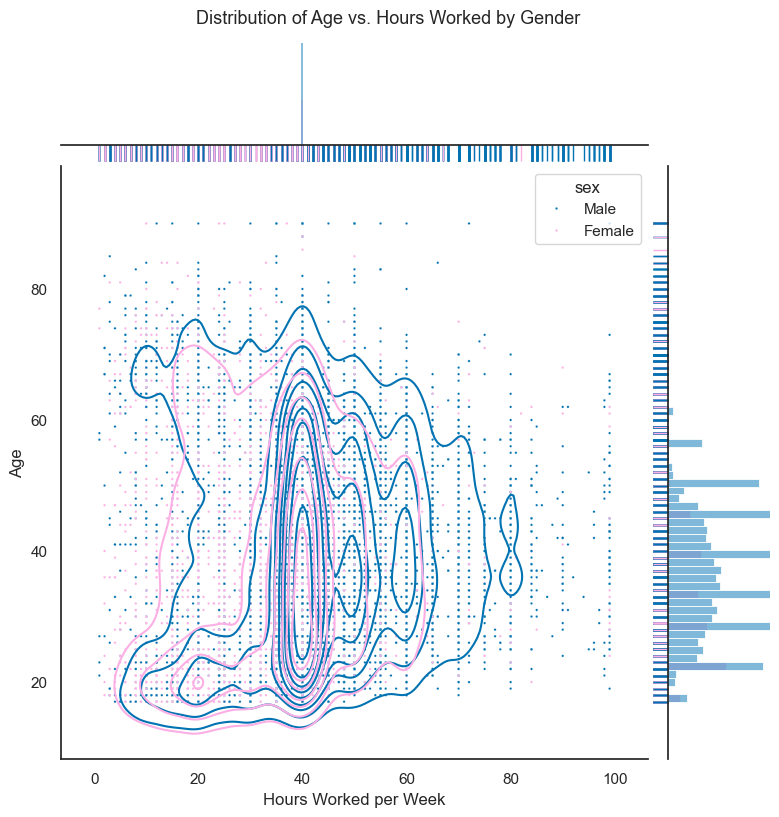

In [56]:
# set runtime parameters
sns.set(style = "white",
        palette =  ['#0173b2','#fbafe4'])
# create jointgrid
g2b = sns.JointGrid(data = df, x = "hours_per_week", y="age", hue="sex", 
                   hue_order = ["Male","Female"],
                   height = 8
                   )
g2b.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
# create joint plots with the JointGrid method plot_joints
g2b.plot_joint(sns.kdeplot)
g2b.plot_joint(sns.scatterplot, s=3)
# create the marginal plots with the JointGrid method plot_marginals
g2b.plot_marginals(sns.histplot)
g2b.plot_marginals(sns.rugplot, height=-.15, clip_on=False)
# add a title
g2b.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 13, y = 1.02)
plt.show()

#### Using JointGrid and its axes

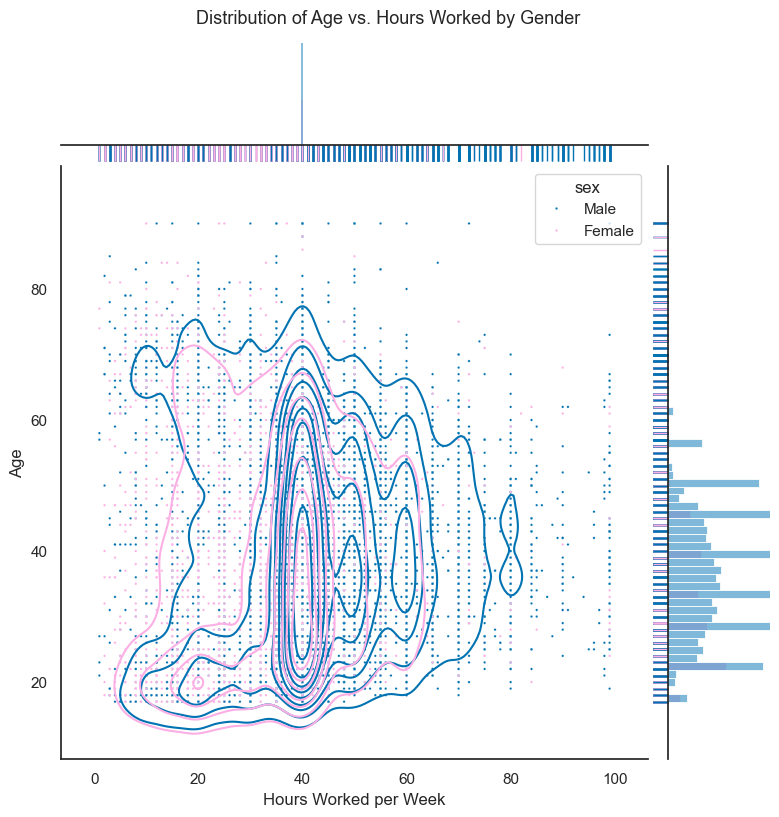

In [57]:
# set runtime parameters
sns.set(style = "white",
        palette =  ['#0173b2','#fbafe4'])
# create jointgrid
g2b = sns.JointGrid(data = df, x = "hours_per_week", y="age", hue="sex", 
                   hue_order = ["Male","Female"],
                   height = 8
                   )
g2b.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
# create joint plots using the axes
g2b.plot_joint(sns.kdeplot)
g2b.plot_joint(sns.scatterplot, s=3)
# create the marginal plots with the JointGrid method plot_marginals
g2b.plot_marginals(sns.histplot)
g2b.plot_marginals(sns.rugplot, height=-.15, clip_on=False)
# add a title
g2b.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 13, y = 1.02)
plt.show()

#### Bivariate Histogram

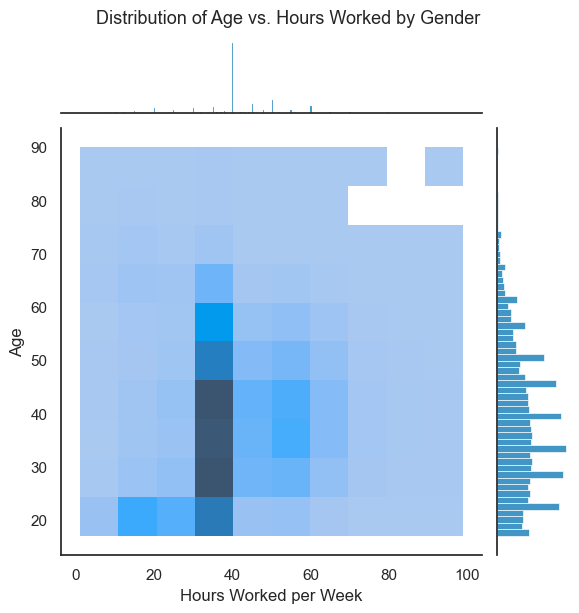

In [58]:
sns.set(style = "white",
        palette =  ['#0173b2','#fbafe4'])
g2_hist = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   kind = "hist",
                   height = 6,
                   bins = 10
                   )
g2_hist.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
# g2.plot_joint(sns.scatterplot, s=3)
# g2.plot_marginals(sns.rugplot, height=-.15, clip_on=False)
# sns.scatterplot(data = df, x = "hours_per_week", y="age", hue="sex", ax = g2.ax_joint, s = 3)
g2_hist.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 13, y = 1.02)
plt.show()

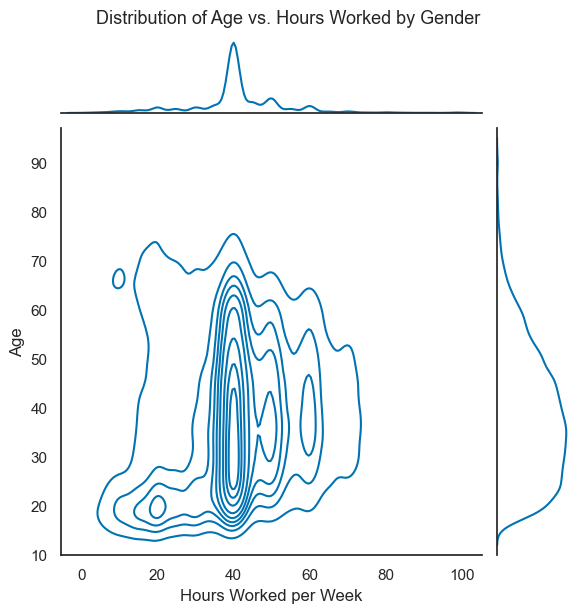

In [59]:
sns.set(style = "white",
        palette =  ['#0173b2','#fbafe4'])
g2_hist = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   kind = "kde",
                   height = 6
                   )
g2_hist.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
# g2.plot_joint(sns.scatterplot, s=3)
# g2.plot_marginals(sns.rugplot, height=-.15, clip_on=False)
# sns.scatterplot(data = df, x = "hours_per_week", y="age", hue="sex", ax = g2.ax_joint, s = 3)
g2_hist.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 13, y = 1.02)
plt.show()

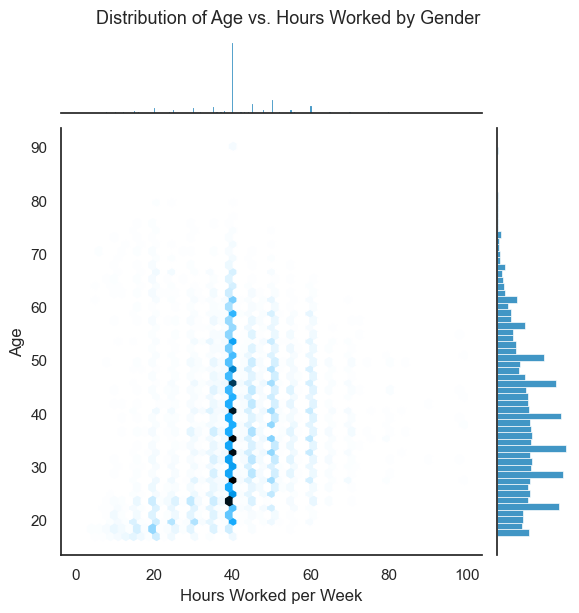

In [60]:
sns.set(style = "white",
        palette =  ['#0173b2','#fbafe4'])
g2_hist = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   kind = "hex",
                   height = 6
                   )
g2_hist.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
# g2.plot_joint(sns.scatterplot, s=3)
# g2.plot_marginals(sns.rugplot, height=-.15, clip_on=False)
# sns.scatterplot(data = df, x = "hours_per_week", y="age", hue="sex", ax = g2.ax_joint, s = 3)
g2_hist.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 13, y = 1.02)
plt.show()

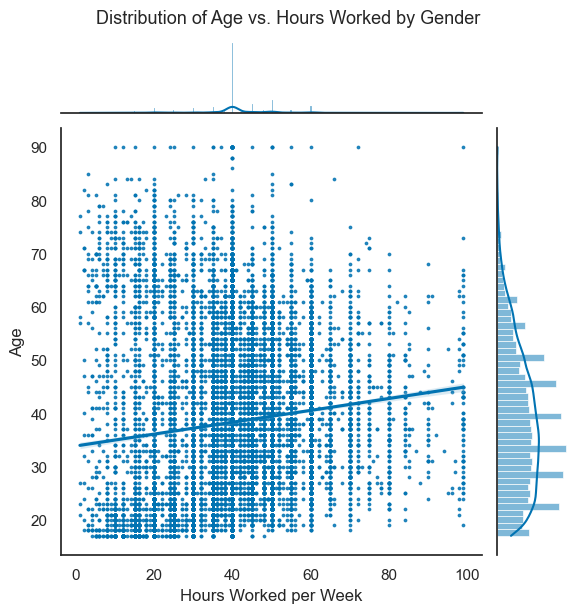

In [61]:
sns.set(style = "white",
        palette =  ['#0173b2','#fbafe4'])
g2_hist = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   kind = "reg",
                   height = 6,
                   joint_kws = dict(scatter_kws=(dict(s=3)))
                   )
g2_hist.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
# g2.plot_joint(sns.scatterplot, s=3)
# g2.plot_marginals(sns.rugplot, height=-.15, clip_on=False)
# sns.scatterplot(data = df, x = "hours_per_week", y="age", hue="sex", ax = g2.ax_joint, s = 3)
g2_hist.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 13, y = 1.02)
plt.show()

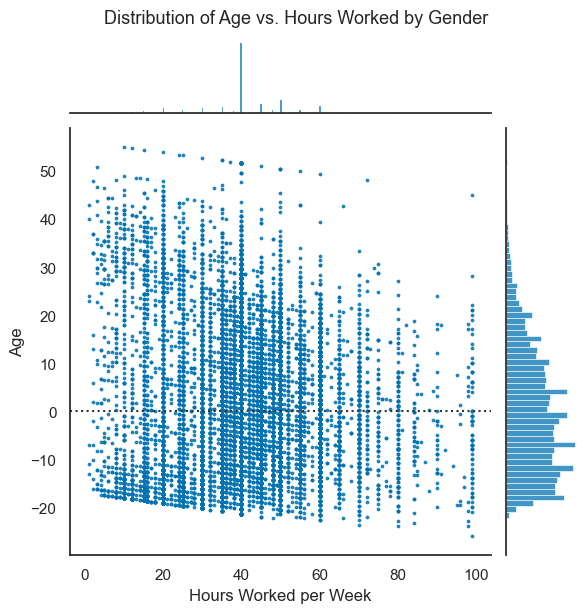

In [62]:
sns.set(style = "white",
        palette =  ['#0173b2','#fbafe4'])
g2_hist = sns.jointplot(data = df, x = "hours_per_week", y="age", 
                   kind = "resid",
                   height = 6,
                   joint_kws = dict(scatter_kws=(dict(s=3)))                   )
g2_hist.set_axis_labels(xlabel = "Hours Worked per Week", ylabel = "Age")
# g2.plot_joint(sns.scatterplot, s=3)
# g2.plot_marginals(sns.rugplot, height=-.15, clip_on=False)
# sns.scatterplot(data = df, x = "hours_per_week", y="age", hue="sex", ax = g2.ax_joint, s = 3)
g2_hist.figure.suptitle("Distribution of Age vs. Hours Worked by Gender", size = 13, y = 1.02)
plt.show()

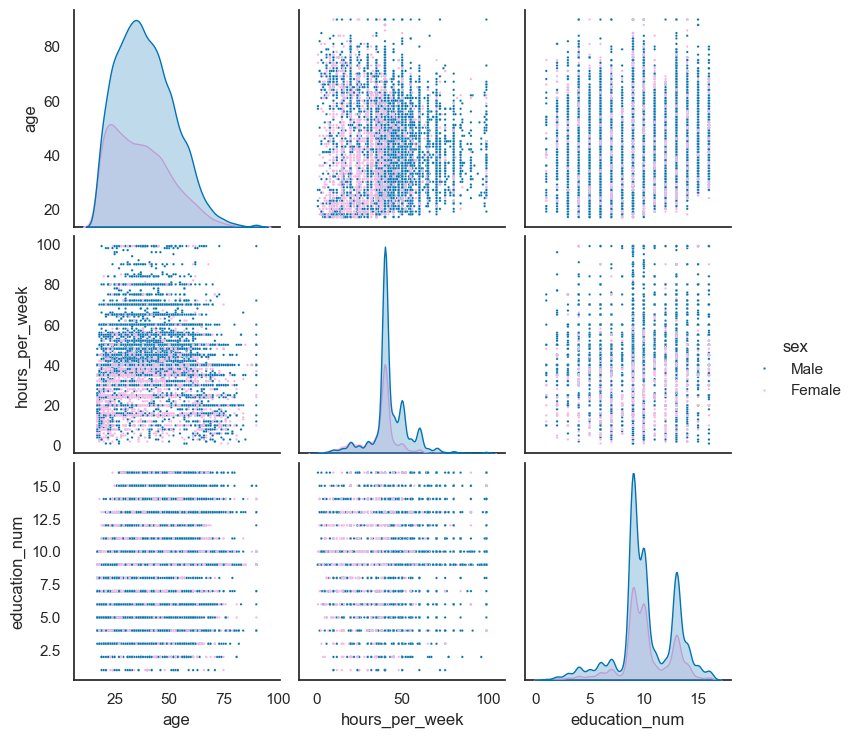

In [63]:
df_small = df[["age","hours_per_week","education_num","sex"]]
sns.pairplot(data = df_small,  hue = "sex", diag_kind = "kde", plot_kws = { "s" : 3})

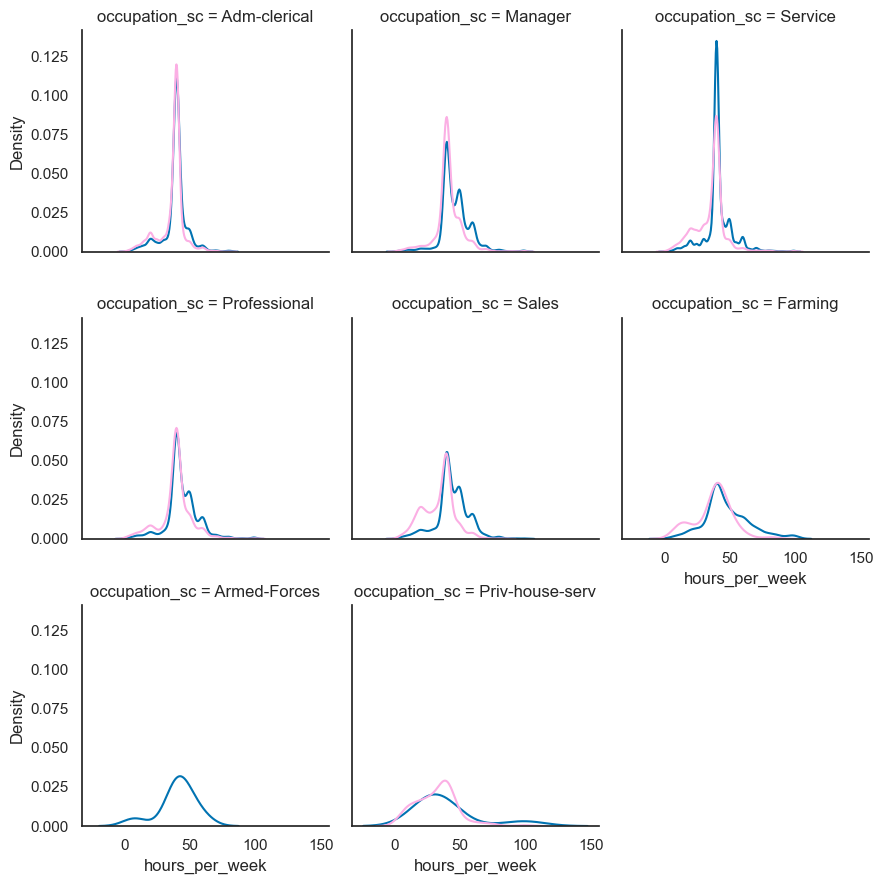

In [64]:
g = sns.FacetGrid(data = df,  col= "occupation_sc", hue = "sex", col_wrap = 3 )
g.map(sns.kdeplot, "hours_per_week")
plt.show()

### 7. Visualize regression lines between years of education and hours worked per week.

You can use the Seaborn lmplot() method to visualize bivariate data and the regression mode.   
Plot separate regression lines on different columns (subplots in columns) for each 'occupation category’.   
For each plot use ‘education-num’ on the x-axis and ‘hours-per-week’ on the y-axis.    
Differentiate between two sexes using the hue argument.   
To display just the regression line, you can set the scatter argument to false in lmplot().   

In [65]:
df.occupation_sc.unique()

array(['Adm-clerical', 'Manager', 'Service', 'Professional', 'Sales',
       'Farming', 'Armed-Forces', 'Priv-house-serv'], dtype=object)

<Axes: xlabel='education_num', ylabel='hours_per_week'>

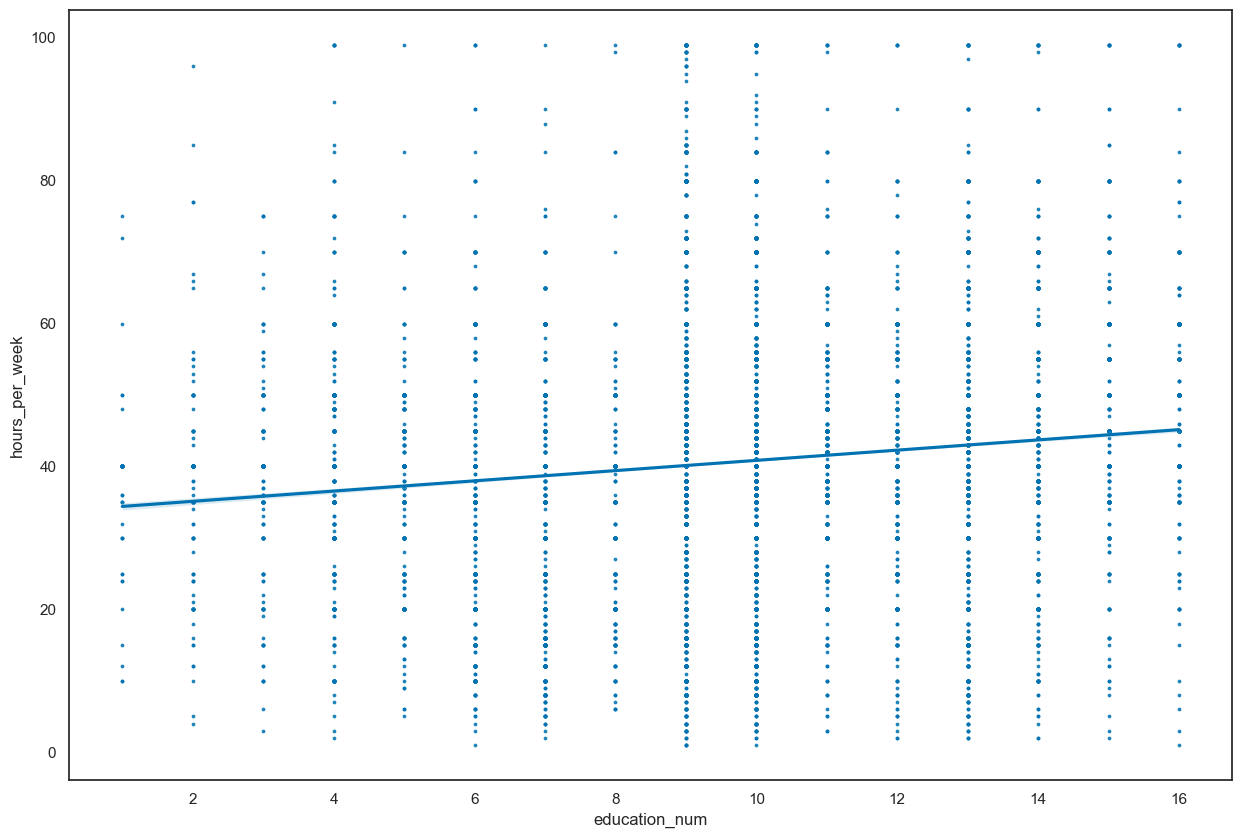

In [66]:
sns.regplot(data = df, x = "education_num", y="hours_per_week",
                scatter_kws = dict(s=3))

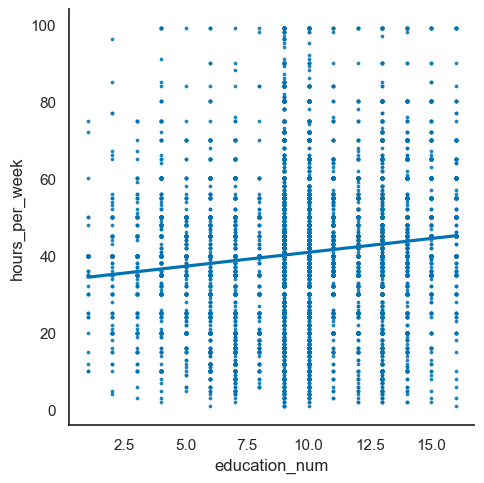

In [67]:
g2 = sns.lmplot(data = df, x = "education_num", y="hours_per_week",
                scatter_kws = dict(s=3))
plt.show()

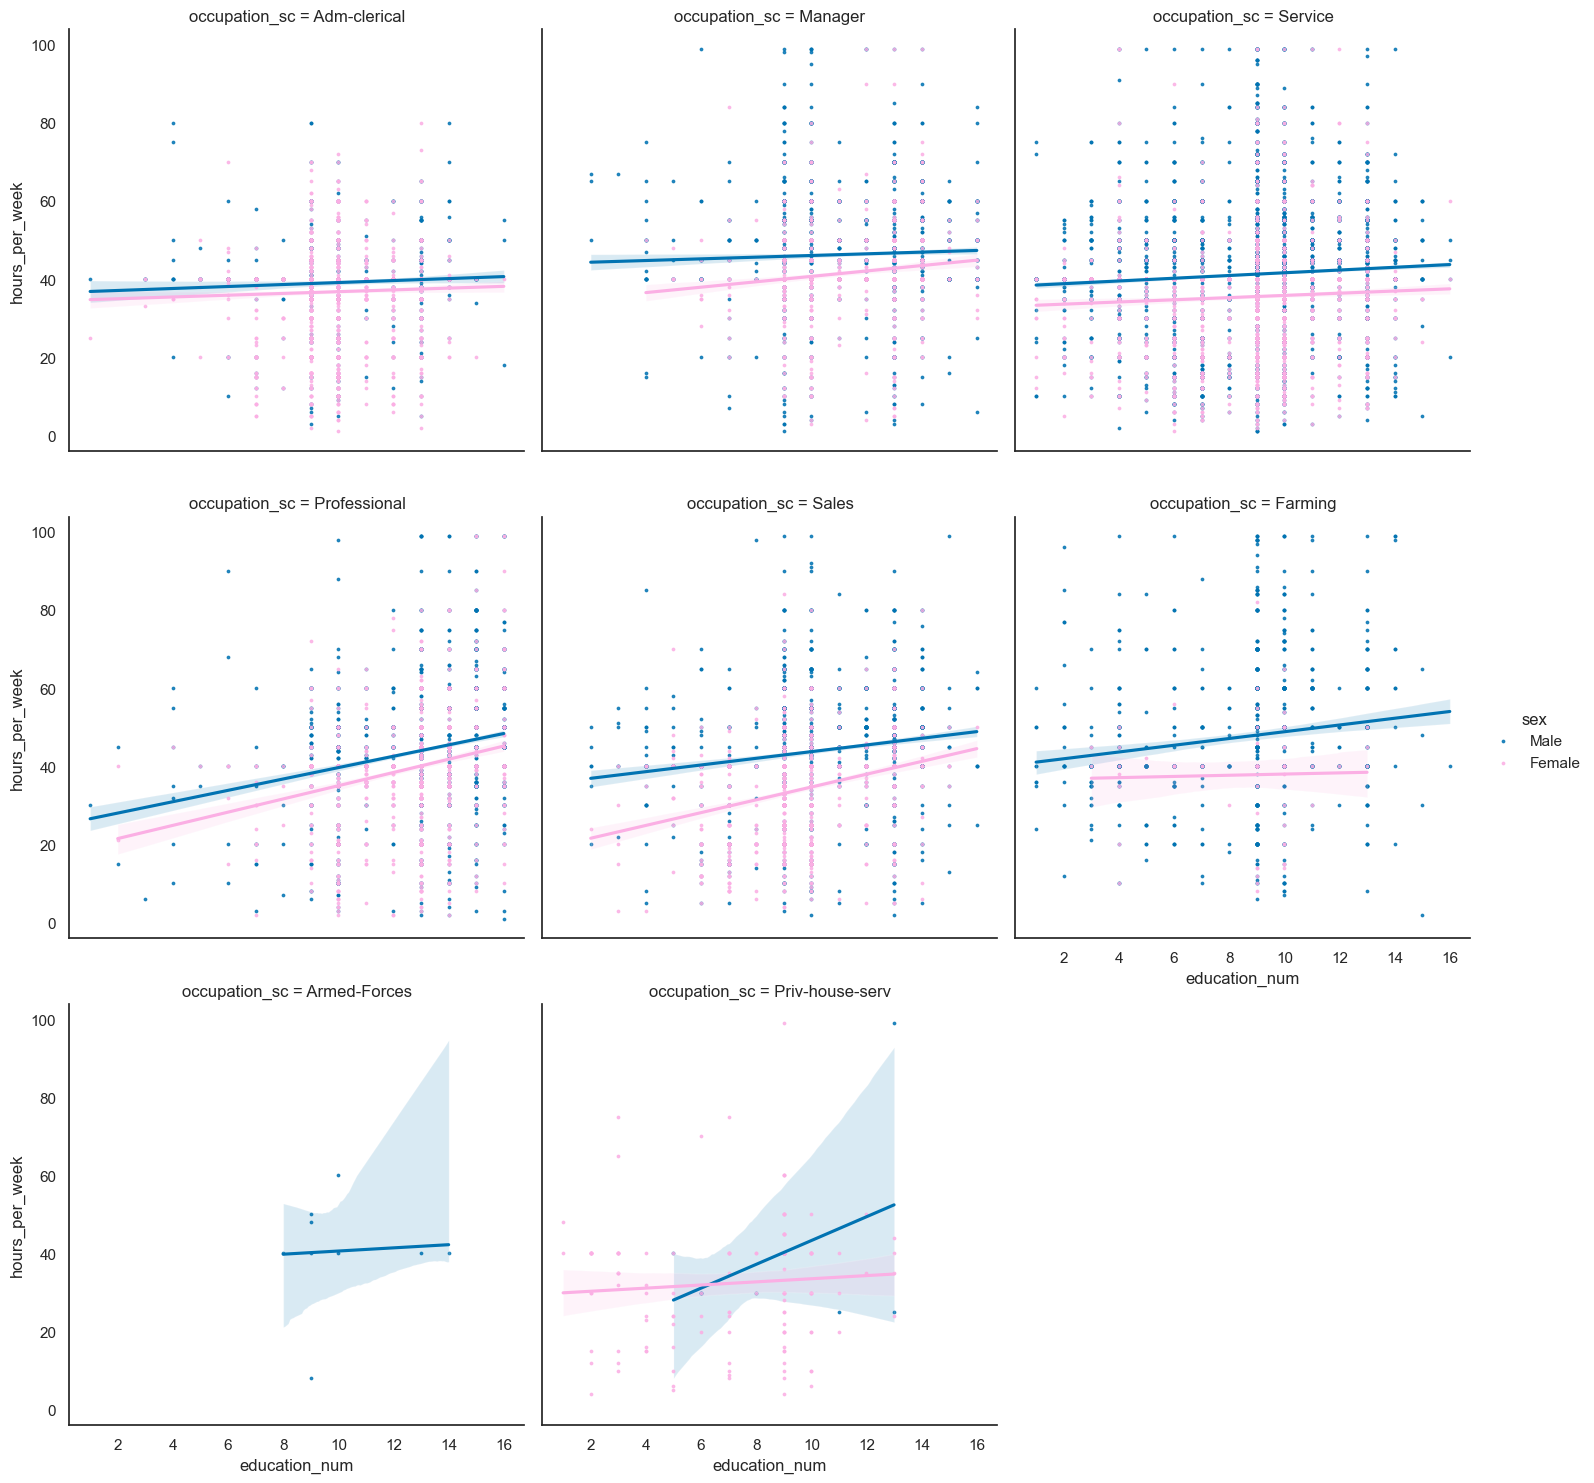

In [68]:
g2 = sns.lmplot(data = df, x = "education_num", y="hours_per_week", 
                hue="sex", col = "occupation_sc", col_wrap = 3, 
                palette = ['#0173b2','#fbafe4'],
                scatter_kws = dict(s=3))
plt.show()

In [69]:
type(g2)

seaborn.axisgrid.FacetGrid

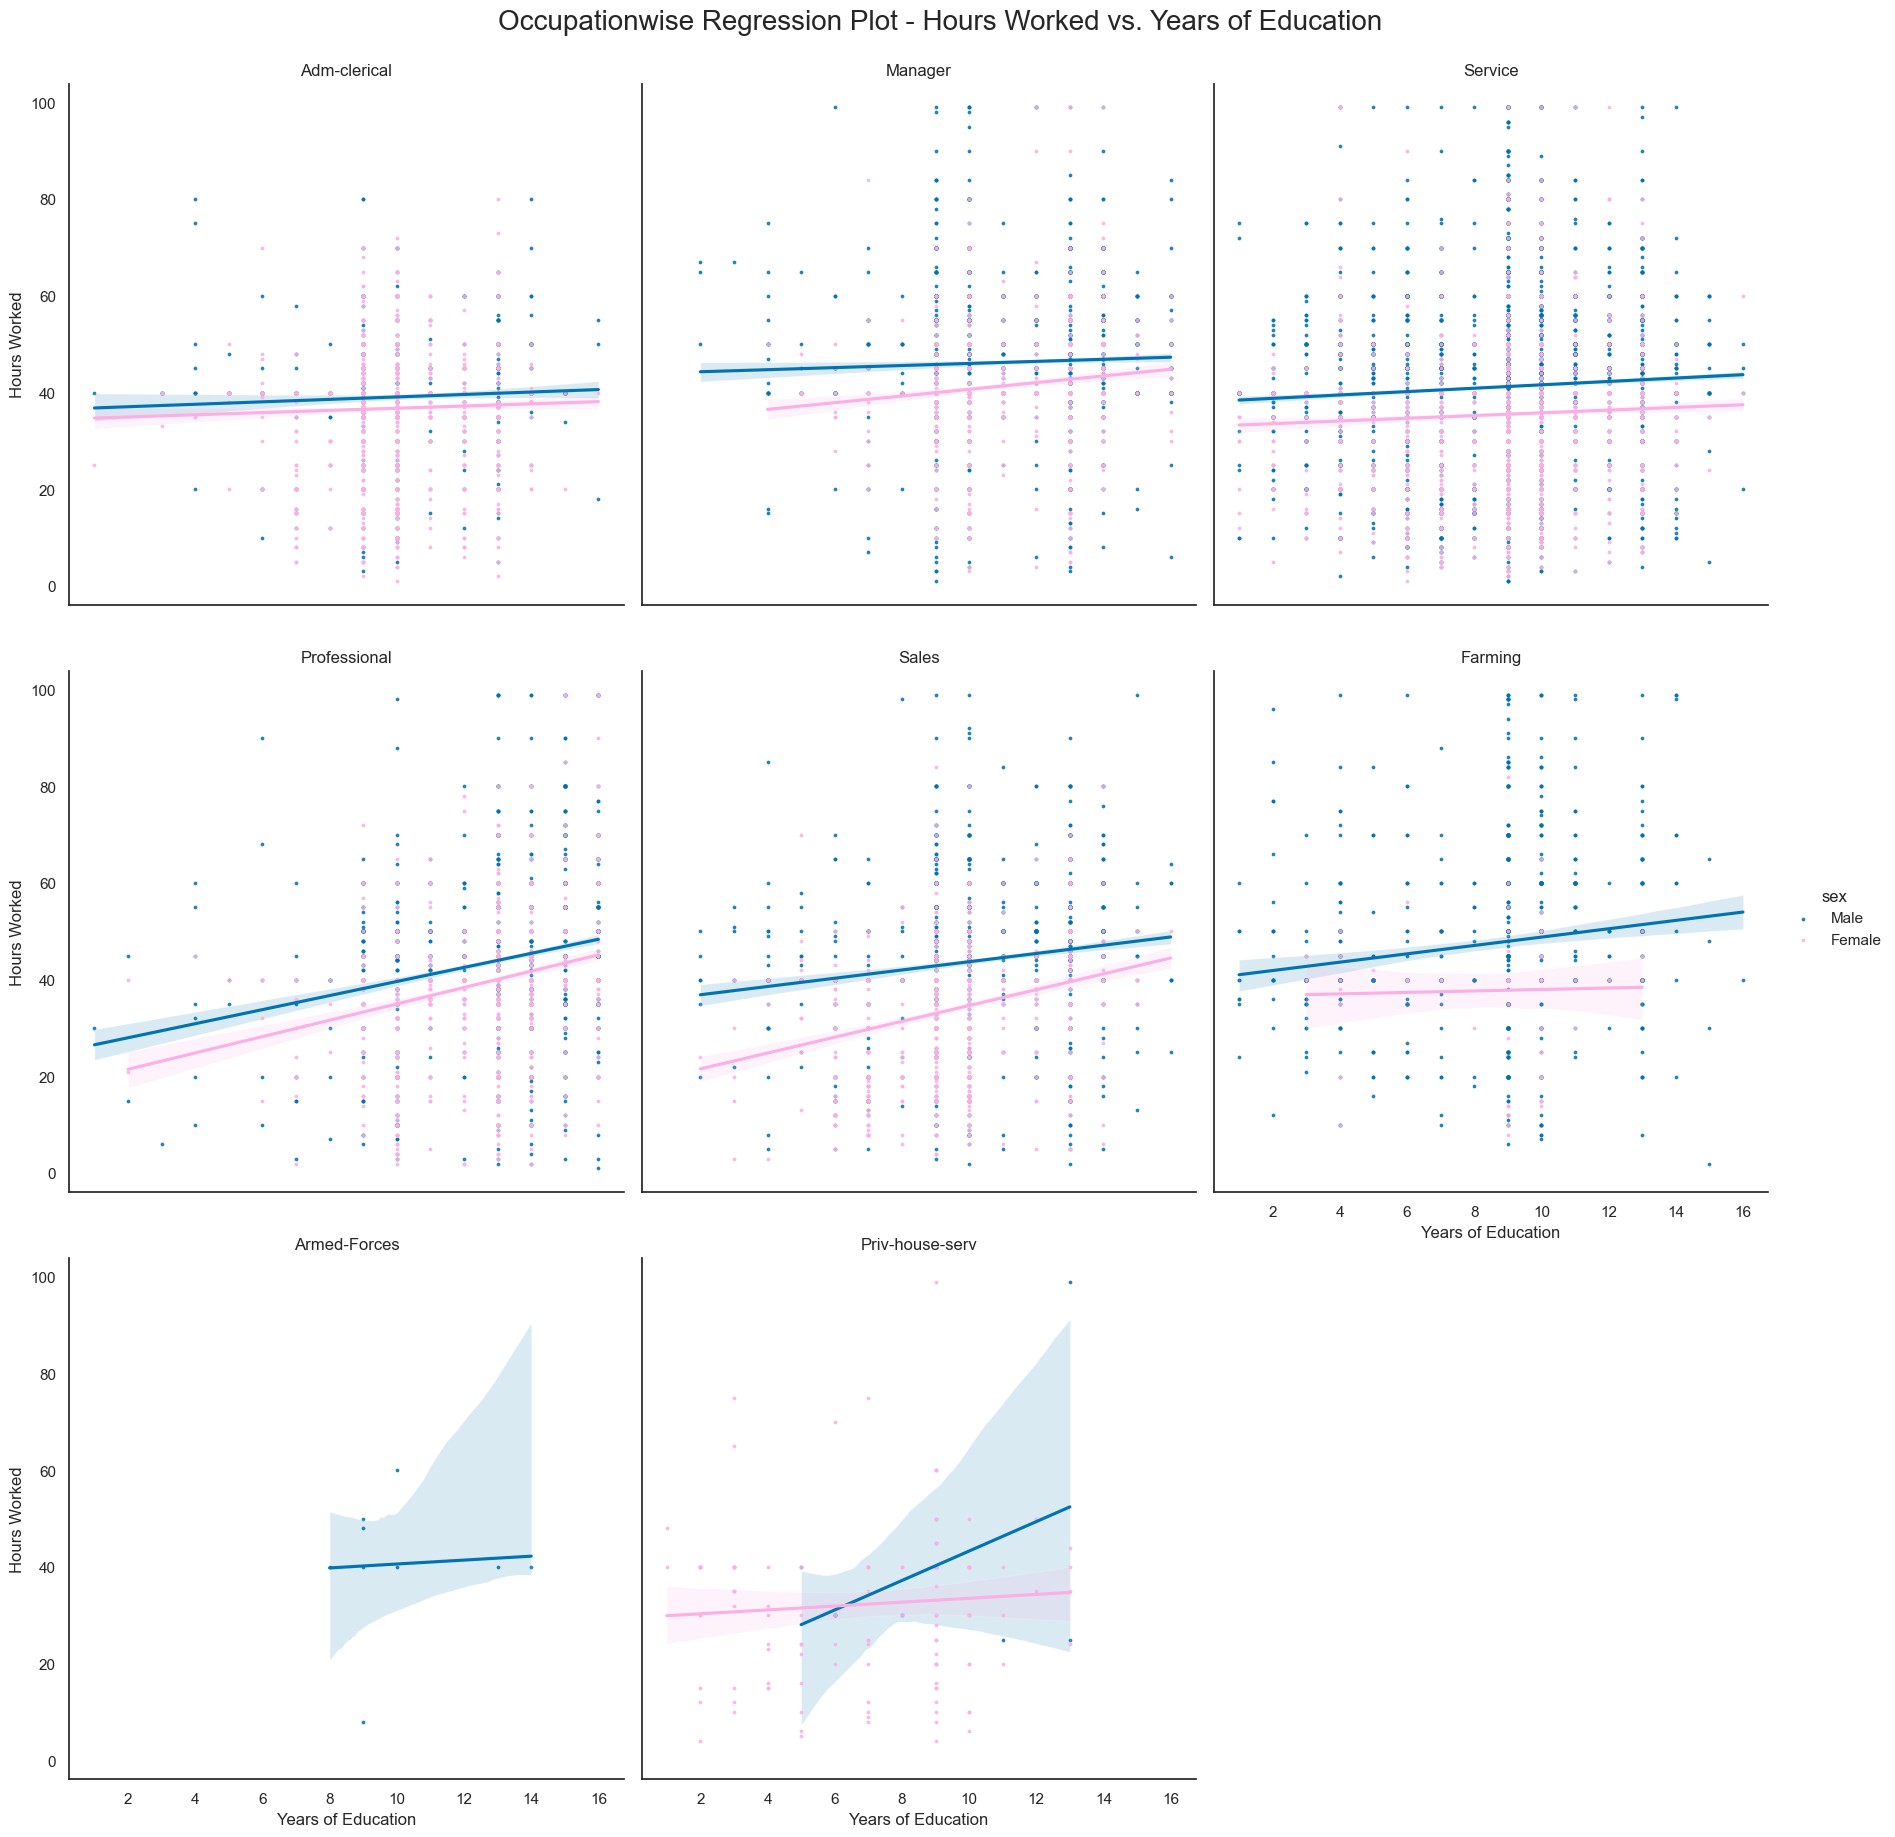

In [70]:
g2 = sns.lmplot(data = df, x = "education_num", y="hours_per_week", 
                hue="sex", col = "occupation_sc", col_wrap = 3, 
                palette = ['#0173b2','#fbafe4'],
                scatter_kws = dict(s=3), height = 6)

g2.set_axis_labels("Years of Education", "Hours Worked")

grid_title = "Occupationwise Regression Plot - Hours Worked vs. Years of Education"
g2.figure.suptitle(grid_title, size = 20, y = 1.02)

g2.set_titles(col_template="{col_name}")

g2.savefig(img_loc+"P3_M3_regplots.png", dpi = 400)

plt.show()

### 8. Set axis labels and plot title and save your plot as a png file with the desired resolution.

#### Regressions

In [71]:
from sklearn.linear_model import LinearRegression

In [72]:
occupation = "Adm-clerical"
sex = "Male"
df_small = df[(df.occupation_sc == occupation) & (df.sex == sex)]
x = np.array(df_small.education_num).reshape((-1,1))
y = np.array(df_small.hours_per_week)
model = LinearRegression()
model.fit(x,y)
r_sq = model.score(x, y)
print(f"coefficient of determination: {r_sq}")
print(f"intercept: {model.intercept_}")
print(f"slope: {model.coef_}")

coefficient of determination: 0.00284660331215858
intercept: 36.57268639867009
slope: [0.25366772]


In [73]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [74]:
sm.__version__

'0.14.2'

In [75]:
occupation = "Adm-clerical"
sex = "Female"
df_small = df[(df.occupation_sc == occupation) & (df.sex == sex)]
formula = "hours_per_week ~ education_num"
model = smf.ols(formula, df_small)
fit = model.fit()
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         hours_per_week   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.312
Date:                Mon, 01 Sep 2025   Prob (F-statistic):             0.0689
Time:                        17:44:42   Log-Likelihood:                -9239.3
No. Observations:                2512   AIC:                         1.848e+04
Df Residuals:                    2510   BIC:                         1.849e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        34.5105      1.258     27.423      0.000      32.043      36.978
education_num     0.2265      0.124      1.820      0.069      -0.018       0.471
==============================================================================
Omnibus:                      385.324   Durbin-Watson:                   1.991
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              841.960
Skew:                          -0.895   Prob(JB):                    1.48e-183
Kurtosis:                       5.201   Cond. No.                         67.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""